# Proportions

In [1]:
%config InlineBackend.figure_format = 'retina'

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sp
from plotnine import *
import mizani

from matplotlib import pyplot as plt
from tqdm.auto import tqdm

from statsmodels.stats.multitest import multipletests

In [3]:
import sys

sys.path.append('/home/gokcen/Code/sctoolkit/')

In [4]:
from sctoolkit.proportions import dirichletreg, bin_pval, get_proportions_per_channel, plot_proportion_barplot

In [5]:
%load_ext rpy2.ipython

In [6]:
sc.set_figure_params(dpi=90)

In [7]:
sc.settings.verbosity = 'hint'

In [8]:
pd.options.display.max_rows = 500

In [9]:
from io import StringIO

s = '''old	new
Keratinocyte 1	KC 1
Proliferating keratinocytes	KC cycling
Keratinocyte 2	KC 2
Keratinocyte 3	KC 3
Keratinocyte 4	KC 4
Keratinocyte 5	KC 5
Cornified keratinocytes 1	Cornified KC 1
Cornified keratinocytes 2	Cornified KC 2
Hair follicle 1	HF
Hair follicle 2	Sweat gland 1
Hair follicle 3	Sweat gland 2
Sebaceous gland	Sebaceous gland
Sweat gland	Sweat gland 3
Fibroblast COL23A1+NKD2+	FB papillary
Fibroblast CCL19+TNC hi	FB CCL19+IL4I1+
Fibroblast CCL19+	FB CCL19+APOE+
Fibroblast IGF1+APOD hi	FB APOC1+
Fibroblast TIMP1 hi	FB GDF10+
Fibroblast PTN hi CPE hi	FB CPE+
Fibroblast C2orf40+CDH19+	FB CDH19+
Fibroblast C2orf40+NGFR+	FB NGFR+
Fibroblast SLPI+	FB reticular
Fibroblast DPEP1+	FB DPEP1+
Fibroblast COCH+	FB dermal papilla
Pericyte RGS5 lo	PE TGFBI+
Pericyte RGS5 hi	PE RGS hi
Pericyte/SMC MYH11-	PE/SMC GEM hi
SMC PLN	SMC RERGL+
Myocytes	SMC DES+
Arterial EC IGFBP3+	ArtEC ICAM2 hi
Arterial EC IGFBP3+IL6+	ArtEC SOS1 hi
Capillary EC FABP4 hi	CapEC FABP4+
Capillary EC EDNRB hi	CapEC EDNRB hi
EC EDNRB hi MCAM hi	CapEC INSR hi
Venule EC IL6+	VenEC IL6+
Venule EC ACKR1 lo SELE lo	VenEC CCL15 hi
Venule EC ACKR1 hi	VenEC CCL14 hi
Arterial EC RGS5+ IGFBP3+	ArtEC RGS5+ICAM2hi+
Capillary EC RGS5+ FABP4 hi	CapEC RGS5+FABP4+
Capillary EC RGS5+ EDNRB hi	CapEC RGS5+EDNRB hi
EC RGS5+ EDNRB hi MCAM hi	CapEC RGS5+ INSR+
Venule EC RGS5+ ACKR1 hi	VenEC RGS5+CCL14hi
LEC	LEC
Melanocytes S100A4-	Melano S100A4-
Melanocytes S100A4+	Melano S100A4+
Melanocytes IFI27 hi	Melano IFI27 hi
Schwann MBP+	Schwann MBP+
Schwann NRXN1 hi SCN7A hi	Schwann NRXN1 hi
Schwann ETV1+	Schwann LAMP5+
Schwann DCN+	Schwann DCN+
DC1	DC 1
Proliferating DC1	DC 1 cycling
DC2	DC 2
DC2 CD83+	DC 2 CD83+
Proliferating DC2	DC 2 cycling
Langerhans DC	LDC
DC MMP12 hi LAMP3 lo	DC MMP12+
mmDC LAMP3+	mmDC
DC MMP9+CCR7+	DC IL1B+
MΦ MMP9+CCR7+	MΦ IL1B+
MΦ FNIP2 hi	MΦ FNIP2 hi
MΦ FNIP2 lo	MΦ EGR1+
MΦ C1QA hi	MΦ C1QA hi
MΦ STAB1 hi	MΦ STAB1 hi
MΦ TREM2 hi	MΦ SPP1+
Neutrophils	Neutrophil
Mast CDC42EP3 hi	Mast CDC42EP3 hi
Mast CD69 hi	Mast CD69 hi
Mast CD63 hi	Mast CD63 hi
Mast Proliferating	Mast cycling
Naive/Memory B cell	B Naive/Mem
Plasmablast	Plasmablast
Plasma cells IgA/IgM	Plasma IgA
Plasma cells IgG	Plasma IgG
NK	NK
NK (MB+)	ILC
NK (MB+) Activated	ILC cycling
γδ T cells	γδ T
CD8 Effector IFNg low	CD8+ CTL
CD8 Effector IFNg hi	CD8+ CTL IFNG hi
CD4 Tregs	Treg
Proliferating CD4 Tregs	Treg cycling
T cells CREM hi	T CREM hi
T cells CREM lo FOS lo	T CREM lo FOS lo
T cells FOS hi	T FOS hi
Proliferating T cells FOS hi	T FOS hi cycling'''

m = pd.read_table(StringIO(s)).set_index('old').new.to_dict()

In [10]:
pco = pd.read_excel('proportion-results-coarse.xlsx').drop(columns='coef_type')
pco.variable = pco.variable.str.replace('disease_lesional', '')
pco.to_excel('SuppTable2-A.xlsx', index=False)

In [11]:
pgr = pd.read_excel('proportion-results-granular.xlsx').drop(columns='coef_type')
pgr.variable = pgr.variable.str.replace('disease_lesional', '')
pgr.compartment = pgr.compartment.map(m)
pgr.to_excel('SuppTable2-B.xlsx', index=False)

In [10]:
adata = sc.read('AtopicDermatitis.h5ad')

In [13]:
'Cornified keratinocytes 2' in adata.obs['Cell type granular'].unique()

True

In [14]:
adata.obs['Cell type granular'].unique()

['Fibroblast C2orf40+NGFR+', 'Fibroblast COL23A1+NKD2+', 'Fibroblast PTN hi CPE hi', 'Fibroblast IGF1+APOD hi', 'Fibroblast CCL19+', ..., 'Pericyte/SMC MYH11-', 'Schwann NRXN1 hi SCN7A hi', 'Schwann MBP+', 'Schwann DCN+', 'Schwann ETV1+']
Length: 86
Categories (86, object): ['Keratinocyte 1', 'Proliferating keratinocytes', 'Keratinocyte 2', 'Keratinocyte 3', ..., 'T cells CREM hi', 'T cells CREM lo FOS lo', 'T cells FOS hi', 'Proliferating T cells FOS hi']

## Coarse cell types

In [11]:
ad = adata[(~adata.obs.ind_id.isin(['BCH04', 'BCH07']))].copy()

In [16]:
ad

AnnData object with n_obs × n_vars = 238402 × 29991
    obs: '10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'predicted_sex', 'raw', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell type', 'Cell type granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'childbearing_potential', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease score (MADAD Immune)', 'Disease score (MADAD Full)', 'Disease score (MADAD Union)', 'Cell type new cornified', 'ind_disease_lesional', 'Cell states

In [12]:
t2t = ad.obs[['Cell type', 'Cell type granular']].drop_duplicates().set_index('Cell type granular').to_dict()['Cell type']

### Model: alternative parameterization one vs rest with disease precision

In [13]:
model3 = []

for x in tqdm(ad.obs['Cell type'].cat.categories):
    print(x)
    try:
        model3.append(dirichletreg(ad, 'channel', 'Cell type', ['chemistry_10x', 'disease_lesional'], 'y ~ chemistry_10x + disease_lesional | disease_lesional', onevsrest_category=x))
    except:
        print('ERROR')
        try:
            model3.append(dirichletreg(ad, 'channel', 'Cell type', ['chemistry_10x', 'disease_lesional'], 'y ~ disease_lesional', onevsrest_category=x))
        except:
            pass

model3 = pd.concat(model3, axis=0)

model3 = model3[model3.variable != '(Intercept)']
s, p, _, _ = multipletests(model3.pval, alpha=0.1, method='fdr_bh')
model3['significant'] = s
model3['pval_adj'] = p
model3['neg_log10_pval_adj'] = -np.log10(p+1e-200)
model3['significance'] = bin_pval(model3.pval_adj)
model3 = model3[['compartment', 'variable', 'se', 'zval', 'pval', 'significant', 'pval_adj', 'coef_type', 'coefficient', 'neg_log10_pval_adj', 'significance']].reset_index(drop=True)

model3[model3.variable.str.startswith('disease_lesional') & (model3.coef_type == 'mean')]

  0%|          | 0/16 [00:00<?, ?it/s]

Keratinocytes


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


Cornified keratinocytes


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


...

Plasma


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


T/NK


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


,compartment,variable,se,zval,pval,significant,pval_adj,coef_type,coefficient,neg_log10_pval_adj,significance
1,Keratinocytes,disease_lesionalNon-lesional,0.293092,-1.392086,1.638964e-01,False,2.804450e-01,mean,-0.408009,0.552152,
2,Keratinocytes,disease_lesionalLesional,0.224505,-0.866737,3.860863e-01,False,5.398808e-01,mean,-0.194587,0.267702,
6,Cornified keratinocytes,disease_lesionalNon-lesional,0.270905,0.404422,6.859024e-01,False,8.125305e-01,mean,0.109560,0.090160,
7,Cornified keratinocytes,disease_lesionalLesional,0.249017,-0.854838,3.926406e-01,False,5.398808e-01,mean,-0.212870,0.267702,
11,Sweat gland,disease_lesionalNon-lesional,0.220791,-0.938662,3.479045e-01,False,5.054461e-01,mean,-0.207248,0.296325,
12,Sweat gland,disease_lesionalLesional,0.112376,-5.355298,8.541569e-08,True,1.315402e-06,mean,-0.601808,5.880942,***
16,Fibroblasts,disease_lesionalNon-lesional,0.251991,2.202922,2.760026e-02,True,7.931803e-02,mean,0.555117,1.100628,.
17,Fibroblasts,disease_lesionalLesional,0.131137,1.788512,7.369341e-02,False,1.587832e-01,mean,0.234540,0.799195,
21,Pericyte/SMC,disease_lesionalNon-lesional,0.172802,-2.765152,5.689630e-03,True,2.738135e-02,mean,-0.477824,1.562545,*
22,Pericyte/SMC,disease_lesionalLesional,0.115699,-6.644675,3.038872e-11,True,1.169966e-09,mean,-0.768779,8.931827,***


In [24]:
model3[model3.variable.str.startswith('disease_lesional') & (model3.coef_type == 'mean')].to_csv('heather_pval_ct_H_NL+L_correct.csv')

In [19]:
model3[model3.variable.str.startswith('disease_lesional') & (model3.coef_type == 'mean')].reset_index(drop=True).to_excel('proportion-results-coarse.xlsx', index=False)

In [20]:
props, covs = get_proportions_per_channel(ad, 'channel', 'Cell type', ['disease_lesional'])

In [21]:
proportion_df = props.reset_index().melt('channel', var_name='Cell type', value_name='proportion').merge(covs.reset_index())
proportion_df['Cell type'] = pd.Categorical(proportion_df['Cell type'], ad.obs['Cell type'].cat.categories)
proportion_df

,channel,Cell type,proportion,disease_lesional
0,Healthy1-H1,Keratinocytes,0.608541,Healthy
1,Healthy1-H1,Cornified keratinocytes,0.001814,Healthy
2,Healthy1-H1,Sweat gland,0.022539,Healthy
3,Healthy1-H1,Fibroblasts,0.150513,Healthy
4,Healthy1-H1,Pericyte/SMC,0.071802,Healthy
...,...,...,...,...
523,MGH110-L,Neutrophils,0.000210,Lesional
524,MGH110-L,Mast,0.009351,Lesional
525,MGH110-L,B cells,0.000105,Lesional
526,MGH110-L,Plasma,0.007039,Lesional


In [22]:
proportion_df[['channel', 'disease_lesional']].drop_duplicates().disease_lesional.value_counts()

Lesional        14
Non-lesional    12
Healthy          7
Name: disease_lesional, dtype: int64

g = (
    ggplot(proportion_df, aes(x='Cell type', y='proportion+0.001')) + 
    #geom_dotplot(position='dodge', binaxis = "y", stackdir = "center", binwidth = 0.01) + 
    geom_boxplot(aes(fill='disease_lesional'), outlier_shape='') + 
    geom_point(aes(group='disease_lesional', fill='disease_lesional'), position=position_jitterdodge(jitter_width=0.2, jitter_height=0), size=0.1) +    
    facet_wrap('Cell type', nrow=1, scales='free') + 
    scale_fill_manual(values=['#4F9B6C', '#3C75AF',  '#EF8636']) + 
    labs(y='Proportions', x='', fill='Disease status') + 
    theme_classic() + 
    scale_y_continuous(labels=mizani.formatters.percent) +
    #scale_y_continuous(trans='log10') + 
    theme(figure_size=(25,3.5), axis_text_x = element_text(angle = 90, hjust = 0.5), panel_spacing_x=.6, strip_text=element_blank(), strip_background=element_blank())
)

ggsave(g, 'figures/figure01/proportion-celltype-boxplots.pdf')
g

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 20 x 4 in image



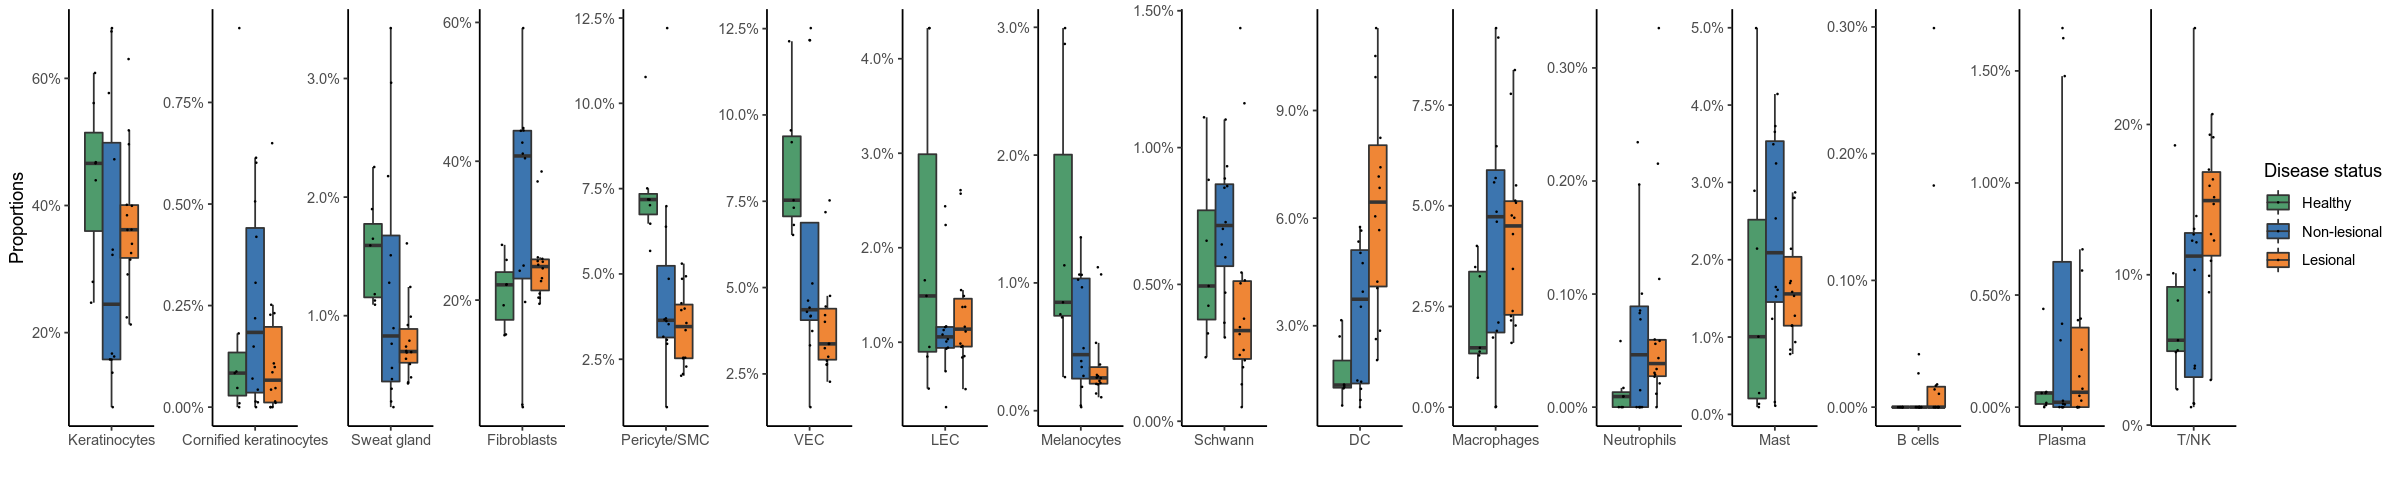

In [23]:
%%R -i proportion_df -w 20 -h 4 -u in -r 120

library(ggplot2)

g = (
    ggplot(proportion_df, aes(x=`Cell type`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape = NA) +
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +
    facet_wrap(~`Cell type`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Proportions', x='', fill='Disease status')
)

ggsave('figures/figure01/boxplot-coarse-celltype-proportions.pdf', device=cairo_pdf)

g

g = (
    ggplot(proportion_df, aes(x='Cell type', y='proportion+0.001', fill='disease_lesional')) + 
    #geom_dotplot(position='dodge', binaxis = "y", stackdir = "center", binwidth = 0.01) + 
    geom_boxplot() + 
    #facet_wrap('Cell type', nrow=1, scales='free') + 
    scale_fill_manual(values=['#4F9B6C', '#3C75AF',  '#EF8636']) + 
    labs(y='Proportions', x='', fill='Disease status') + 
    theme_classic() + 
    scale_y_continuous(labels=mizani.formatters.percent) +
    #scale_y_continuous(trans='log10') + 
    theme(figure_size=(10,4), axis_text_x = element_text(angle = 90, hjust = 0.5))
)

ggsave(g, 'figures/figure01/proportion-celltype-boxplots-singleaxis.pdf')
g

## NL vs L coarse comparisons

In [25]:
ad.obs['Cell type']

TTTATGCCAATGCCAT-1-BCH01-NL2    Fibroblasts
CGAGAAGTCAATCTCT-1-BCH01-L1     Fibroblasts
AAACGGGAGTGTACCT-1-BCH01-NL1    Fibroblasts
AAACGGGGTGTCTGAT-1-BCH01-NL1    Fibroblasts
AAAGATGGTTGCGTTA-1-BCH01-NL1    Fibroblasts
                                   ...     
TCTTGCGAGGGCAGAG-1-MGH110-L         Schwann
TGAATCGAGTTGGCGA-1-MGH110-L         Schwann
TTACCATCAAATGCGG-1-MGH110-L         Schwann
TTGGGATTCTAGTCAG-1-MGH110-L         Schwann
TTTCCTCGTAGCGTCC-1-MGH110-L         Schwann
Name: Cell type, Length: 238402, dtype: category
Categories (16, object): ['Keratinocytes', 'Cornified keratinocytes', 'Sweat gland', 'Fibroblasts', ..., 'Mast', 'B cells', 'Plasma', 'T/NK']

In [26]:
model3_nll = []

ad_nll = ad[ad.obs.disease_lesional != 'Healthy'].copy()

for x in tqdm(ad.obs['Cell type'].cat.categories):
    print(x)
    try:
        model3_nll.append(dirichletreg(ad_nll, 'channel', 'Cell type', ['chemistry_10x', 'disease_lesional'], 'y ~ chemistry_10x + disease_lesional | disease_lesional', onevsrest_category=x))
    except:
        print('ERROR')
        try:
            model3_nll.append(dirichletreg(ad_nll, 'channel', 'Cell type', ['chemistry_10x', 'disease_lesional'], 'y ~ disease_lesional', onevsrest_category=x))
        except:
            pass

model3_nll = pd.concat(model3_nll, axis=0)

model3_nll = model3_nll[model3_nll.variable != '(Intercept)']
s, p, _, _ = multipletests(model3_nll.pval, alpha=0.1, method='fdr_bh')
model3_nll['significant'] = s
model3_nll['pval_adj'] = p
model3_nll['neg_log10_pval_adj'] = -np.log10(p+1e-200)
model3_nll['significance'] = bin_pval(model3_nll.pval_adj)
model3_nll = model3_nll[['compartment', 'variable', 'se', 'zval', 'pval', 'significant', 'pval_adj', 'coef_type', 'coefficient', 'neg_log10_pval_adj', 'significance']].reset_index(drop=True)

model3_nll[model3_nll.variable.str.startswith('disease_lesional') & (model3_nll.coef_type == 'mean')]

  0%|          | 0/16 [00:00<?, ?it/s]

Keratinocytes


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


Cornified keratinocytes


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


...

Plasma


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


T/NK


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


,compartment,variable,se,zval,pval,significant,pval_adj,coef_type,coefficient,neg_log10_pval_adj,significance
1,Keratinocytes,disease_lesionalLesional,0.251895,0.875604,0.381245,False,0.461508,mean,0.220560,0.335821,
4,Cornified keratinocytes,disease_lesionalLesional,0.166623,-1.675546,0.093827,False,0.159854,mean,-0.279184,0.796278,
7,Sweat gland,disease_lesionalLesional,0.192008,-1.920905,0.054744,False,0.131746,mean,-0.368828,0.880262,
10,Fibroblasts,disease_lesionalLesional,0.225923,-1.440908,0.149611,False,0.217318,mean,-0.325535,0.662905,
13,Pericyte/SMC,disease_lesionalLesional,0.163114,-1.721915,0.085085,False,0.157398,mean,-0.280868,0.803002,
16,VEC,disease_lesionalLesional,0.171493,-2.348895,0.018829,True,0.066627,mean,-0.402819,1.176353,.
19,LEC,disease_lesionalLesional,0.080185,1.418991,0.155902,False,0.217318,mean,0.113782,0.662905,
22,Melanocytes,disease_lesionalLesional,0.167747,-1.931011,0.053482,False,0.131746,mean,-0.323922,0.880262,
25,Schwann,disease_lesionalLesional,0.135864,-2.362084,0.018173,True,0.066627,mean,-0.320922,1.176353,.
28,DC,disease_lesionalLesional,0.219892,2.934495,0.003341,True,0.019210,mean,0.645271,1.716468,*


## Proportion of granular cell types (per island)

new_cats = np.array([x if x != 'Cornified keratinocytes 1' else 'Cornified keratinocytes' for x in ad.obs['Cell type granular'].cat.categories if x != 'Cornified keratinocytes 2'])
new_cats

ad.obs['Cell type granular'] = ad.obs['Cell type granular'].astype(str)
ad.obs['Cell type granular'].loc[ad.obs['Cell type granular'].str.startswith('Cornified')] = 'Cornified keratinocytes'
ad.obs['Cell type granular'] = pd.Categorical(ad.obs['Cell type granular'], categories=new_cats)
ad.obs['Cell type granular']

In [27]:
ad.obs['Cell type'].loc[ad.obs['Cell type granular'].str.startswith('Cornified keratinocytes')] = 'Keratinocytes'
ad.obs['Cell type'].cat.remove_unused_categories(inplace=True)
ad.obs['Cell type']

<ipython-input-27-845bd20c3fc9>:2: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.


TTTATGCCAATGCCAT-1-BCH01-NL2    Fibroblasts
CGAGAAGTCAATCTCT-1-BCH01-L1     Fibroblasts
AAACGGGAGTGTACCT-1-BCH01-NL1    Fibroblasts
AAACGGGGTGTCTGAT-1-BCH01-NL1    Fibroblasts
AAAGATGGTTGCGTTA-1-BCH01-NL1    Fibroblasts
                                   ...     
TCTTGCGAGGGCAGAG-1-MGH110-L         Schwann
TGAATCGAGTTGGCGA-1-MGH110-L         Schwann
TTACCATCAAATGCGG-1-MGH110-L         Schwann
TTGGGATTCTAGTCAG-1-MGH110-L         Schwann
TTTCCTCGTAGCGTCC-1-MGH110-L         Schwann
Name: Cell type, Length: 238402, dtype: category
Categories (15, object): ['Keratinocytes', 'Sweat gland', 'Fibroblasts', 'Pericyte/SMC', ..., 'Mast', 'B cells', 'Plasma', 'T/NK']

In [28]:
new_cats = [x for x in ad.obs['Cell type'].cat.categories if x != 'T/NK'] + ['T', 'NK']
new_cats

['Keratinocytes',
 'Sweat gland',
 'Fibroblasts',
 'Pericyte/SMC',
 'VEC',
 'LEC',
 'Melanocytes',
 'Schwann',
 'DC',
 'Macrophages',
 'Neutrophils',
 'Mast',
 'B cells',
 'Plasma',
 'T',
 'NK']

In [29]:
ad.obs['Cell type'] = ad.obs['Cell type'].astype(str)
ad.obs['Cell type'].loc[ad.obs['Cell type granular'].str.startswith('NK')] = 'NK'
ad.obs['Cell type'].loc[ad.obs['Cell type'] == 'T/NK'] = 'T'
ad.obs['Cell type'] = pd.Categorical(ad.obs['Cell type'], categories=new_cats)
ad.obs['Cell type']

<ipython-input-29-f9a96451a3a7>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<ipython-input-29-f9a96451a3a7>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


TTTATGCCAATGCCAT-1-BCH01-NL2    Fibroblasts
CGAGAAGTCAATCTCT-1-BCH01-L1     Fibroblasts
AAACGGGAGTGTACCT-1-BCH01-NL1    Fibroblasts
AAACGGGGTGTCTGAT-1-BCH01-NL1    Fibroblasts
AAAGATGGTTGCGTTA-1-BCH01-NL1    Fibroblasts
                                   ...     
TCTTGCGAGGGCAGAG-1-MGH110-L         Schwann
TGAATCGAGTTGGCGA-1-MGH110-L         Schwann
TTACCATCAAATGCGG-1-MGH110-L         Schwann
TTGGGATTCTAGTCAG-1-MGH110-L         Schwann
TTTCCTCGTAGCGTCC-1-MGH110-L         Schwann
Name: Cell type, Length: 238402, dtype: category
Categories (16, object): ['Keratinocytes', 'Sweat gland', 'Fibroblasts', 'Pericyte/SMC', ..., 'B cells', 'Plasma', 'T', 'NK']

In [30]:
t2t = ad.obs[['Cell type', 'Cell type granular']].drop_duplicates().set_index('Cell type granular').to_dict()['Cell type']
t2t['Cornified keratinocytes 2'] = 'Keratinocytes'
t2t['Cornified keratinocytes 1'] = 'Keratinocytes'
t2t

{'Fibroblast C2orf40+NGFR+': 'Fibroblasts',
 'Fibroblast COL23A1+NKD2+': 'Fibroblasts',
 'Fibroblast PTN hi CPE hi': 'Fibroblasts',
 'Fibroblast IGF1+APOD hi': 'Fibroblasts',
 'Fibroblast CCL19+': 'Fibroblasts',
 'Fibroblast C2orf40+CDH19+': 'Fibroblasts',
 'Fibroblast SLPI+': 'Fibroblasts',
 'Fibroblast TIMP1 hi': 'Fibroblasts',
 'Fibroblast COCH+': 'Fibroblasts',
 'Fibroblast DPEP1+': 'Fibroblasts',
 'Fibroblast CCL19+TNC hi': 'Fibroblasts',
 'Plasma cells IgG': 'Plasma',
 'T cells CREM lo FOS lo': 'T',
 'CD8 Effector IFNg hi': 'T',
 'T cells FOS hi': 'T',
 'Keratinocyte 1': 'Keratinocytes',
 'Sweat gland': 'Sweat gland',
 'Sebaceous gland': 'Sweat gland',
 'Keratinocyte 3': 'Keratinocytes',
 'Keratinocyte 4': 'Keratinocytes',
 'Keratinocyte 5': 'Keratinocytes',
 'Keratinocyte 2': 'Keratinocytes',
 'Proliferating keratinocytes': 'Keratinocytes',
 'Hair follicle 1': 'Keratinocytes',
 'Hair follicle 2': 'Sweat gland',
 'Hair follicle 3': 'Sweat gland',
 'Cornified keratinocytes 2': 'Ke

In [14]:
ad._sanitize()

### Model 3b: alternative parameterization with disease precision

pd.crosstab(adata.obs['Cell type granular'], adata.obs.channel)

pd.crosstab(ad.obs['Cell type granular'], ad.obs.ind_id)

In [15]:
ad.obs['Cell type'].unique()

['Fibroblasts', 'Plasma', 'T/NK', 'Keratinocytes', 'Sweat gland', ..., 'DC', 'Macrophages', 'Neutrophils', 'Pericyte/SMC', 'Schwann']
Length: 16
Categories (16, object): ['Keratinocytes', 'Cornified keratinocytes', 'Sweat gland', 'Fibroblasts', ..., 'Mast', 'B cells', 'Plasma', 'T/NK']

In [33]:
ad.obs['Cell type test']=np.where(ad.obs['Cell type'].isin(['Keratinocytes','Cornified keratinocytes']),'Kera+corn',ad.obs['Cell type'])
ad.obs['Cell type test'].unique()

# Ensure the column is categorical and remove old categories
if pd.api.types.is_categorical_dtype(ad.obs['Cell type']):
    new_categories = [cat for cat in ad.obs['Cell type'].cat.categories if cat not in ['Keratinocytes', 'Cornified keratinocytes']]
    new_categories.append('Kera+corn')  # Add the new combined category

    # Convert to categorical with updated categories
    ad.obs['Cell type test'] = pd.Categorical(ad.obs['Cell type test'], categories=new_categories, ordered=True)

# Check updated categories
print(ad.obs['Cell type test'].cat.categories)

Index(['Sweat gland', 'Fibroblasts', 'Pericyte/SMC', 'VEC', 'LEC',
       'Melanocytes', 'Schwann', 'DC', 'Macrophages', 'Neutrophils', 'Mast',
       'B cells', 'Plasma', 'T', 'NK', 'Kera+corn'],
      dtype='object')


In [34]:
print(model3b.columns)  # Check available columns


NameError: name 'model3b' is not defined

In [35]:
t2t = ad.obs[['Cell type test', 'Cell type granular v2']].drop_duplicates().set_index('Cell type granular v2').to_dict()['Cell type test']
t2t

{'FB NGFR+': 'Fibroblasts',
 'FB papillary': 'Fibroblasts',
 'FB CPE+': 'Fibroblasts',
 'FB APOC1+': 'Fibroblasts',
 'FB CCL19+APOE+': 'Fibroblasts',
 'FB CDH19+': 'Fibroblasts',
 'FB reticular': 'Fibroblasts',
 'FB GDF10+': 'Fibroblasts',
 'FB dermal papilla': 'Fibroblasts',
 'FB DPEP1+': 'Fibroblasts',
 'FB CCL19+IL4I1+': 'Fibroblasts',
 'Plasma IgG': 'Plasma',
 'T CREM lo FOS lo': 'T',
 'CD8+ CTL IFNG hi': 'T',
 'T FOS hi': 'T',
 'KC 1': 'Kera+corn',
 'Sweat gland 3': 'Sweat gland',
 'Sebaceous gland': 'Sweat gland',
 'KC 3': 'Kera+corn',
 'KC 4': 'Kera+corn',
 'KC 5': 'Kera+corn',
 'KC 2': 'Kera+corn',
 'KC cycling': 'Kera+corn',
 'HF': 'Kera+corn',
 'Sweat gland 1': 'Sweat gland',
 'Sweat gland 2': 'Sweat gland',
 'Cornified KC 2': 'Kera+corn',
 'Cornified KC 1': 'Kera+corn',
 'T CREM hi': 'T',
 'CapEC INSR hi': 'VEC',
 'VenEC CCL14 hi': 'VEC',
 'LEC': 'LEC',
 'VenEC CCL15 hi': 'VEC',
 'CapEC FABP4+': 'VEC',
 'ArtEC ICAM2 hi': 'VEC',
 'VenEC RGS5+ACKR1 hi': 'VEC',
 'CapEC RGS5+EDN

In [19]:
dr_dfs = {}
model3b = []

for ct in tqdm(ad.obs['Cell type'].cat.categories):
    if ct !='T/NK':
        continue
    print(ct)
    

    temp_ad = ad[ad.obs['Cell type'] == ct].copy()
    print(temp_ad.obs[['chemistry_10x', 'disease_lesional']].nunique())
    if temp_ad.obs['Cell type granular'].nunique() == 1:
        continue
        
    df = []
    for x in temp_ad.obs['Cell type granular v2'].cat.categories:
        if x =='Hair follicle 1':
            continue
        print('\t', x)        
        try:
            res = dirichletreg(temp_ad, 'channel', 'Cell type granular v2', ['chemistry_10x', 'disease_lesional'], 'y ~ chemistry_10x + disease_lesional | disease_lesional', onevsrest_category=x, return_reg_input=True)
        except:
            res = dirichletreg(temp_ad, 'channel', 'Cell type granular v2', ['chemistry_10x', 'disease_lesional'], 'y ~ disease_lesional | disease_lesional', onevsrest_category=x, return_reg_input=True)
            print('ERROR')
            continue
        df.append(res)
        
    dr_dfs[ct] = df[0][0]
    
    df = [x[1] for x in df]
    df = pd.concat(df, axis=0)
    model3b.append(df)
    
model3b = pd.concat(model3b, axis=0).reset_index(drop=True)
model3b = model3b[model3b.variable != '(Intercept)']
s, p, _, _ = multipletests(model3b.pval, alpha=0.1, method='fdr_bh')

model3b['significant'] = s
model3b['pval_adj'] = p
model3b['neg_log10_pval_adj'] = -np.log10(p+1e-200)
model3b['significance'] = bin_pval(model3b.pval_adj)
model3b['Cell type'] = model3b['compartment'].map(t2t)
model3b = model3b.sort_values(['Cell type', 'compartment'])
model3b = model3b[['Cell type', 'compartment', 'variable', 'se', 'zval', 'pval', 'significant', 'pval_adj', 'coef_type', 'coefficient', 'neg_log10_pval_adj', 'significance']].reset_index(drop=True)

model3b[model3b.variable.str.startswith('disease_lesional') & (model3b.coef_type == 'mean')]

  0%|          | 0/16 [00:00<?, ?it/s]

T/NK
chemistry_10x       2
disease_lesional    3
dtype: int64
	 NK


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


	 ILC


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


...

	 T FOS hi


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


	 T FOS hi cycling


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


,Cell type,compartment,variable,se,zval,pval,significant,pval_adj,coef_type,coefficient,neg_log10_pval_adj,significance
1,T/NK,NK,disease_lesionalNon-lesional,0.198308,0.441841,6.586042e-01,False,8.224881e-01,mean,0.087621,0.084870,
2,T/NK,NK,disease_lesionalLesional,0.249322,3.557285,3.747075e-04,True,2.043859e-03,mean,0.886911,2.689549,**
6,NaN,CD8+ CTL,disease_lesionalNon-lesional,0.278093,-2.305395,2.114449e-02,True,5.766678e-02,mean,-0.641114,1.239074,.
7,NaN,CD8+ CTL,disease_lesionalLesional,0.309530,-1.996894,4.583673e-02,False,1.057771e-01,mean,-0.618098,0.975608,
11,NaN,CD8+ CTL IFNG hi,disease_lesionalNon-lesional,0.264124,-1.625340,1.040901e-01,False,2.313114e-01,mean,-0.429291,0.635803,
12,NaN,CD8+ CTL IFNG hi,disease_lesionalLesional,0.248765,-2.927252,3.419721e-03,True,1.087254e-02,mean,-0.728197,1.963669,*
16,NaN,ILC,disease_lesionalNon-lesional,0.246265,2.033326,4.201957e-02,False,1.008470e-01,mean,0.500737,0.996337,
17,NaN,ILC,disease_lesionalLesional,0.207117,1.015514,3.098608e-01,False,5.052034e-01,mean,0.210330,0.296534,
21,NaN,ILC cycling,disease_lesionalNon-lesional,0.136375,0.130037,8.965371e-01,False,9.117326e-01,mean,0.017734,0.040133,
22,NaN,ILC cycling,disease_lesionalLesional,0.310624,3.371439,7.477652e-04,True,3.451224e-03,mean,1.047249,2.462027,**


In [37]:
model3b[model3b.variable.str.startswith('disease_lesional') & (model3b.coef_type == 'mean')].to_csv('heather_pval_ct_H_NL+L_correct.csv')

In [71]:
for i in ad.obs['Cell type granular v2'].unique():
    if i.startswith('ArtEC'):
        print(i)

ArtEC ICAM2 hi
ArtEC RGS5+IGFBP3+
ArtEC SOS1 hi


In [39]:
kc = model3b[model3b.variable.str.startswith('disease_lesional') & (model3b.coef_type == 'mean') & (model3b.variable == 'disease_lesionalLesional') & (model3b.compartment != 'Hair follicle 1')]
kc = kc[kc['Cell type test'] == 'Keratinocytes']
kc['compartment'] = kc['compartment'].map(m)
kc['compartment'] = pd.Categorical(kc['compartment'], categories=['KC 1', 'KC cycling', 'KC 2', 'KC 3', 'KC 4', 'KC 5', 'Cornified KC 1', 'Cornified KC 2'])
kc

KeyError: 'Cell type test'

/home/gokcen/.miniconda/lib/python3.8/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/gokcen/.miniconda/lib/python3.8/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: proportion_change_colors.pdf


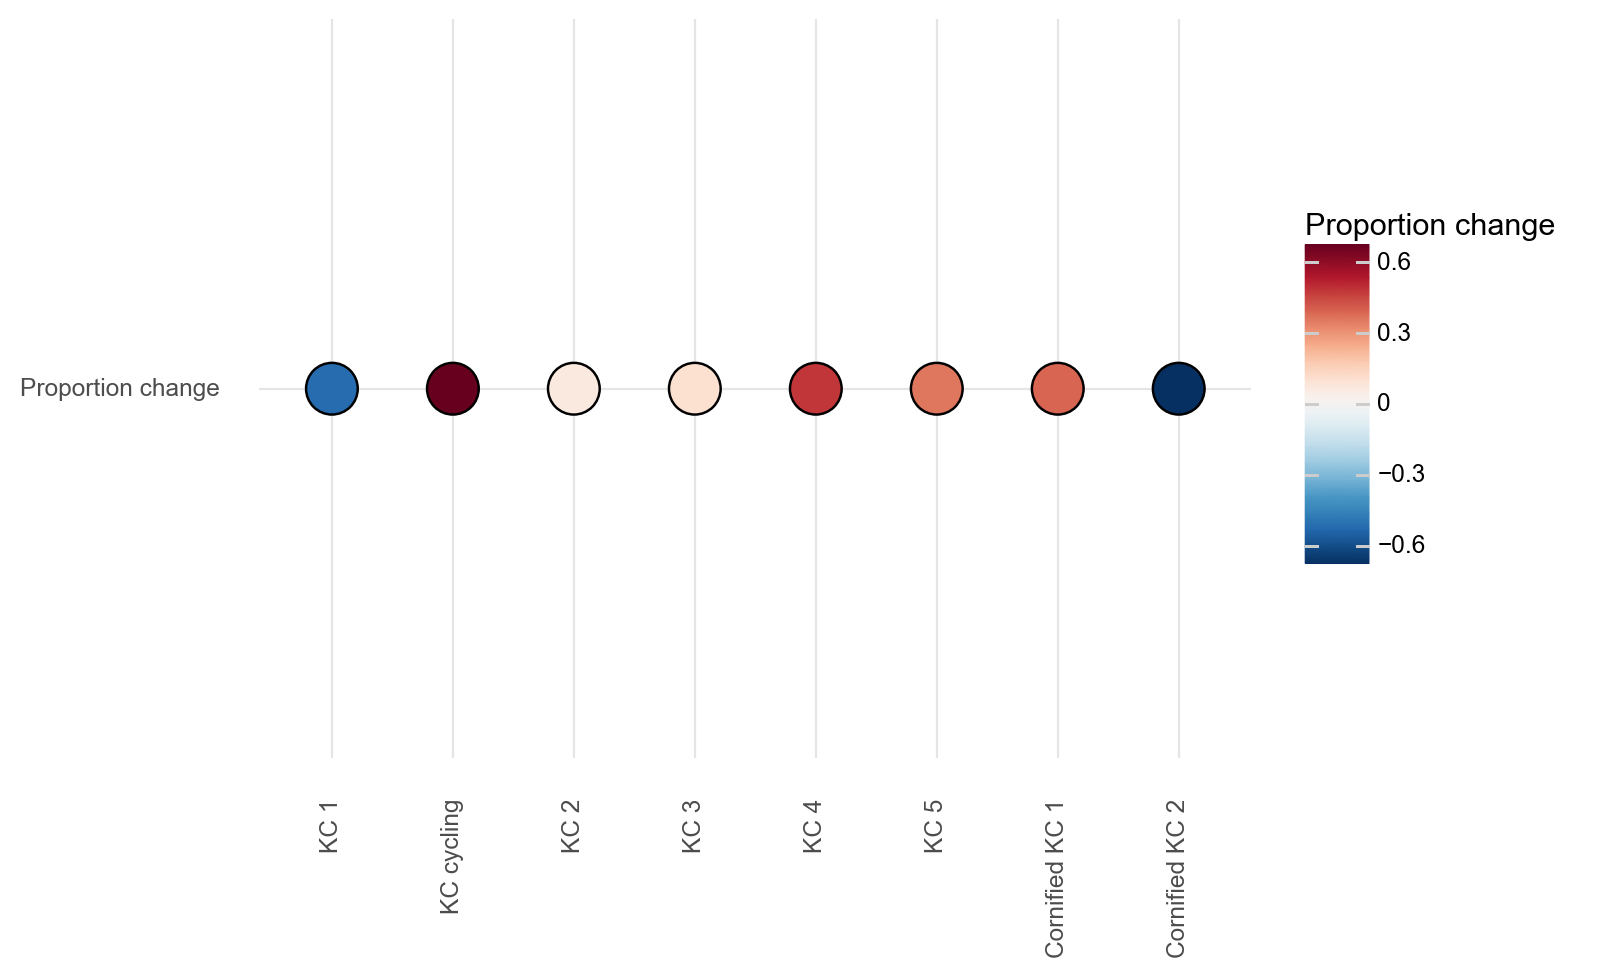

<ggplot: (8748961032873)>

In [106]:
g = ggplot(aes(x='compartment', y='"Proportion change"', fill='coefficient'), kc) + geom_point(size=10) + scale_fill_cmap('RdBu_r') + labs(x='', y='', fill='Proportion change') + theme_minimal() + theme(axis_text_x=element_text(rotation=90), text=element_text(family='Arial')) 

ggsave(g, 'proportion_change_colors.pdf')
g

In [25]:
model3b[model3b.variable.str.startswith('disease_lesional') & (model3b.coef_type == 'mean')].reset_index(drop=True).to_excel('proportion-results-granular.xlsx', index=False)

In [26]:
dr_dfs = pd.concat([dr_dfs[x].reset_index().melt(id_vars=['channel', 'chemistry_10x', 'disease_lesional'], var_name='Cell type granular', value_name='proportion').assign(celltype=x) for x in dr_dfs.keys()], axis=0)
dr_dfs

,channel,chemistry_10x,disease_lesional,Cell type granular,proportion,celltype
0,Healthy1-H1,v3,Healthy,Keratinocyte 1,0.337988,Keratinocytes
1,Healthy2-H2,v3,Healthy,Keratinocyte 1,0.443662,Keratinocytes
2,Healthy5-H51,v2,Healthy,Keratinocyte 1,0.427533,Keratinocytes
3,Healthy5-H52,v2,Healthy,Keratinocyte 1,0.443628,Keratinocytes
4,Healthy6-H6,v3,Healthy,Keratinocyte 1,0.400823,Keratinocytes
...,...,...,...,...,...,...
94,MGH106-L1,v3,Lesional,NK (MB+) Activated,0.076923,NK
95,MGH106-L2,v3,Lesional,NK (MB+) Activated,0.052632,NK
96,MGH108-L1,v3,Lesional,NK (MB+) Activated,0.000000,NK
97,MGH108-L2,v3,Lesional,NK (MB+) Activated,0.086957,NK


## Non-lesional vs Lesional proportion comparisons

In [20]:
ad.obs['Cell type'].cat.categories

Index(['Keratinocytes', 'Cornified keratinocytes', 'Sweat gland',
       'Fibroblasts', 'Pericyte/SMC', 'VEC', 'LEC', 'Melanocytes', 'Schwann',
       'DC', 'Macrophages', 'Neutrophils', 'Mast', 'B cells', 'Plasma',
       'T/NK'],
      dtype='object')

In [21]:
ad_nll = ad[ad.obs.disease_lesional != 'Healthy'].copy()
ad_nll

AnnData object with n_obs × n_vars = 178657 × 29991
    obs: '10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'predicted_sex', 'raw', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell type', 'Cell type granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'childbearing_potential', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease score (MADAD Immune)', 'Disease score (MADAD Full)', 'Disease score (MADAD Union)', 'Cell type new cornified', 'ind_disease_lesional', 'Cell states

In [22]:
ad_nll.obs.disease_lesional

TTTATGCCAATGCCAT-1-BCH01-NL2    Non-lesional
CGAGAAGTCAATCTCT-1-BCH01-L1         Lesional
AAACGGGAGTGTACCT-1-BCH01-NL1    Non-lesional
AAACGGGGTGTCTGAT-1-BCH01-NL1    Non-lesional
AAAGATGGTTGCGTTA-1-BCH01-NL1    Non-lesional
                                    ...     
TCTTGCGAGGGCAGAG-1-MGH110-L         Lesional
TGAATCGAGTTGGCGA-1-MGH110-L         Lesional
TTACCATCAAATGCGG-1-MGH110-L         Lesional
TTGGGATTCTAGTCAG-1-MGH110-L         Lesional
TTTCCTCGTAGCGTCC-1-MGH110-L         Lesional
Name: disease_lesional, Length: 178657, dtype: category
Categories (2, object): ['Non-lesional', 'Lesional']

In [23]:
dr_dfs_NLL = {}
model3b_NLL = []

for ct in tqdm(ad_nll.obs['Cell type'].cat.categories):
    if ct!='T/NK':
        continue
    print(ct)
    temp_ad = ad_nll[ad_nll.obs['Cell type'] == ct].copy()
    if temp_ad.obs['Cell type granular v2'].nunique() == 1:
        continue
        
    df = []
    for x in temp_ad.obs['Cell type granular v2'].cat.categories:
        print('\t', x)        
        try:
            res = dirichletreg(temp_ad, 'channel', 'Cell type granular v2', ['chemistry_10x', 'disease_lesional'], 'y ~ chemistry_10x + disease_lesional | disease_lesional', onevsrest_category=x, return_reg_input=True)
        except:
            res = dirichletreg(temp_ad, 'channel', 'Cell type granular v2', ['chemistry_10x', 'disease_lesional'], 'y ~ disease_lesional | disease_lesional', onevsrest_category=x, return_reg_input=True)
            print('ERROR')
            #continue
        df.append(res)
        
    dr_dfs_NLL[ct] = df[0][0]
    
    df = [x[1] for x in df]
    df = pd.concat(df, axis=0)
    model3b_NLL.append(df)
    
model3b_NLL = pd.concat(model3b_NLL, axis=0).reset_index(drop=True)
model3b_NLL = model3b_NLL[model3b_NLL.variable != '(Intercept)']
s, p, _, _ = multipletests(model3b_NLL.pval, alpha=0.1, method='fdr_bh')

model3b_NLL['significant'] = s
model3b_NLL['pval_adj'] = p
model3b_NLL['neg_log10_pval_adj'] = -np.log10(p+1e-200)
model3b_NLL['significance'] = bin_pval(model3b_NLL.pval_adj)
model3b_NLL['Cell type'] = model3b_NLL['compartment'].map(t2t)
model3b_NLL = model3b_NLL.sort_values(['Cell type', 'compartment'])
model3b_NLL = model3b_NLL[['Cell type', 'compartment', 'variable', 'se', 'zval', 'pval', 'significant', 'pval_adj', 'coef_type', 'coefficient', 'neg_log10_pval_adj', 'significance']].reset_index(drop=True)

model3b_NLL['new_compartment'] = model3b_NLL.compartment.map(m)
model3b_NLL[model3b_NLL.variable.str.startswith('disease_lesional') & (model3b_NLL.coef_type == 'mean')]

  0%|          | 0/16 [00:00<?, ?it/s]

T/NK
	 NK


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


	 ILC


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


...

	 T FOS hi


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


	 T FOS hi cycling


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


,Cell type,compartment,variable,se,zval,pval,significant,pval_adj,coef_type,coefficient,neg_log10_pval_adj,significance,new_compartment
1,T/NK,NK,disease_lesionalLesional,0.206831,3.705937,2.106107e-04,True,6.701251e-04,mean,0.766503,3.173844,***,NK
4,NaN,CD8+ CTL,disease_lesionalLesional,0.260983,0.046880,9.626090e-01,False,9.626090e-01,mean,0.012235,0.016550,,NaN
7,NaN,CD8+ CTL IFNG hi,disease_lesionalLesional,0.175306,-1.733696,8.297202e-02,False,1.528432e-01,mean,-0.303928,0.815754,,NaN
10,NaN,ILC,disease_lesionalLesional,0.232130,-1.187812,2.349076e-01,False,3.574681e-01,mean,-0.275727,0.446763,,NaN
12,NaN,ILC cycling,disease_lesionalLesional,0.281651,3.207864,1.337246e-03,True,3.600278e-03,mean,0.903497,2.443664,**,NaN
15,NaN,T CREM hi,disease_lesionalLesional,0.374857,-0.908400,3.636671e-01,False,4.573628e-01,mean,-0.340520,0.339739,,NaN
18,NaN,T CREM lo FOS lo,disease_lesionalLesional,0.298302,-0.730384,4.651557e-01,False,5.613948e-01,mean,-0.217875,0.250732,,NaN
21,NaN,T FOS hi,disease_lesionalLesional,0.174999,-0.308937,7.573697e-01,False,8.283731e-01,mean,-0.054064,0.081774,,NaN
24,NaN,T FOS hi cycling,disease_lesionalLesional,0.316138,6.096479,1.084304e-09,True,9.487661e-09,mean,1.927328,8.022841,***,NaN
27,NaN,Treg,disease_lesionalLesional,0.229840,1.399566,1.616433e-01,False,2.694056e-01,mean,0.321677,0.569593,,NaN


In [43]:
model3b_NLL[model3b_NLL.variable.str.startswith('disease_lesional') & (model3b_NLL.coef_type == 'mean')].to_csv('heather_pvap_ct_NL_L_correct.csv')

In [42]:
ad[ad.obs['Cell type']=='VEC'].obs[['channel','disease_lesional']].drop_duplicates()['disease_lesional'].value_counts()

Lesional        14
Non-lesional    12
Healthy          7
Name: disease_lesional, dtype: int64

## Proportion volcanos

## Granular

In [108]:
proportion_result = model3b[(model3b.coef_type == 'mean') & (model3b.variable.str.startswith('disease'))]
proportion_result.head()

,Cell type,compartment,variable,se,zval,pval,significant,pval_adj,coef_type,coefficient,neg_log10_pval_adj,significance
1,DC,DC MMP12 hi LAMP3 lo,disease_lesionalNon-lesional,0.433049,4.733968,2.201727e-06,True,0.000034,mean,2.050041,4.471600,***
2,DC,DC MMP12 hi LAMP3 lo,disease_lesionalLesional,0.269921,5.206650,1.922804e-07,True,0.000004,mean,1.405386,5.441487,***
6,DC,DC MMP9+CCR7+,disease_lesionalNon-lesional,0.630353,1.530496,1.258941e-01,False,0.276998,mean,0.964753,0.557524,
7,DC,DC MMP9+CCR7+,disease_lesionalLesional,0.582358,0.753030,4.514319e-01,False,0.651178,mean,0.438533,0.186300,
11,DC,DC1,disease_lesionalNon-lesional,0.305342,-0.735029,4.623217e-01,False,0.655483,mean,-0.224435,0.183438,


In [109]:
proportion_result

,Cell type,compartment,variable,se,zval,pval,significant,pval_adj,coef_type,coefficient,neg_log10_pval_adj,significance
1,DC,DC MMP12 hi LAMP3 lo,disease_lesionalNon-lesional,0.433049,4.733968,2.201727e-06,True,3.375982e-05,mean,2.050041,4.471600,***
2,DC,DC MMP12 hi LAMP3 lo,disease_lesionalLesional,0.269921,5.206650,1.922804e-07,True,3.618368e-06,mean,1.405386,5.441487,***
6,DC,DC MMP9+CCR7+,disease_lesionalNon-lesional,0.630353,1.530496,1.258941e-01,False,2.769977e-01,mean,0.964753,0.557524,
7,DC,DC MMP9+CCR7+,disease_lesionalLesional,0.582358,0.753030,4.514319e-01,False,6.511781e-01,mean,0.438533,0.186300,
11,DC,DC1,disease_lesionalNon-lesional,0.305342,-0.735029,4.623217e-01,False,6.554834e-01,mean,-0.224435,0.183438,
12,DC,DC1,disease_lesionalLesional,0.284933,-1.022770,3.064167e-01,False,5.156768e-01,mean,-0.291421,0.287622,
16,DC,DC2,disease_lesionalNon-lesional,0.274294,-2.659537,7.824824e-03,True,3.207403e-02,mean,-0.729496,1.493846,*
17,DC,DC2,disease_lesionalLesional,0.281475,-0.413858,6.789780e-01,False,8.077496e-01,mean,-0.116491,0.092723,
21,DC,DC2 CD83+,disease_lesionalNon-lesional,0.249442,-2.566698,1.026719e-02,True,3.895329e-02,mean,-0.640241,1.409456,*
22,DC,DC2 CD83+,disease_lesionalLesional,0.142624,-4.333831,1.465367e-05,True,1.956975e-04,mean,-0.618108,3.708415,***


In [28]:
proportion_result.variable.unique()

array(['disease_lesionalNon-lesional', 'disease_lesionalLesional'],
      dtype=object)

sig = proportion_result[proportion_result.significant]
nonsig = proportion_result[~proportion_result.significant]
color_dict = {k:v for k,v in zip(ad.obs['Cell type'].cat.categories, ad.uns['Cell type_colors'])}

(
    ggplot(data=sig, mapping=aes(x='coefficient', y='neg_log10_pval_adj')) + 
    geom_point(data=nonsig, size=1, color='gray') + 
    geom_point(aes(color='Cell type')) + 
    geom_abline(intercept=1, slope=0, color='black', size=0.1) + 
    geom_text(aes(label='compartment'), size=8, 
              adjust_text={'x': proportion_result.coefficient.values, 'y': proportion_result.neg_log10_pval_adj.values, 'expand_points': (1.5,5),
                           'arrowprops': {'arrowstyle': '-', 'color': 'gray', 'lw': 0.5, 'alpha': 0.5}},
              data=proportion_result) +
    scale_color_manual(values=color_dict) + 
    scale_x_continuous(limits=(-sig.coefficient.abs().max(), sig.coefficient.abs().max())) +
    theme_light() +
    theme(figure_size=(14,12))
)

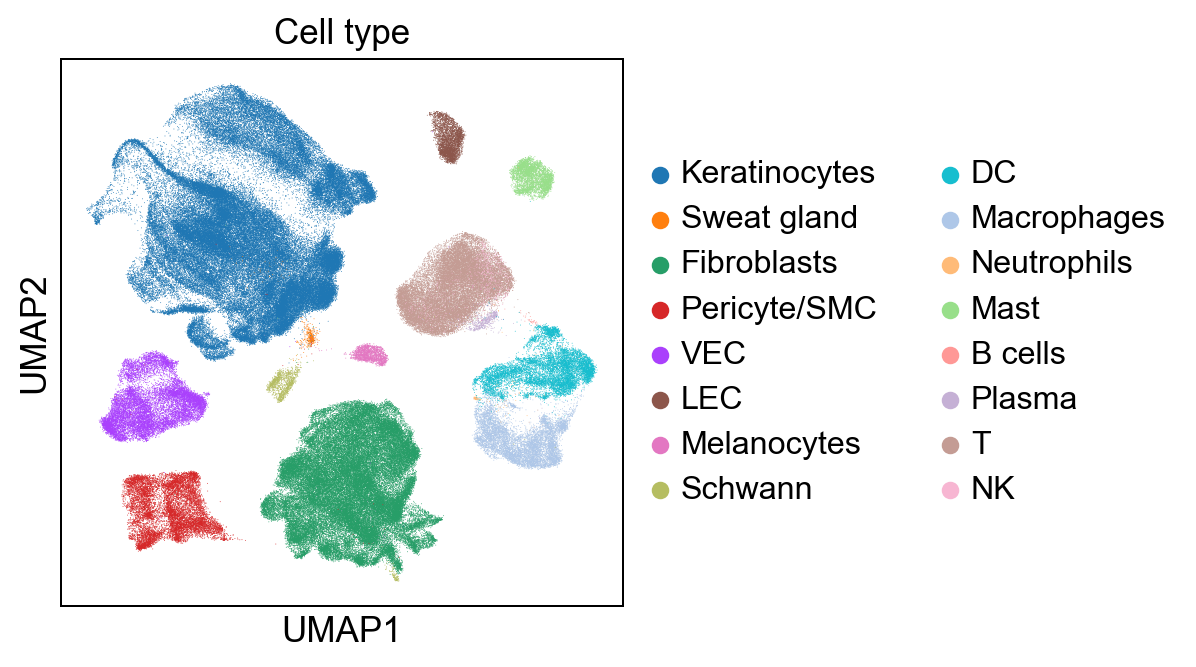

In [29]:
sc.pl.umap(ad, color='Cell type')

In [30]:
ad.obs['Cell type'].cat.categories

Index(['Keratinocytes', 'Sweat gland', 'Fibroblasts', 'Pericyte/SMC', 'VEC',
       'LEC', 'Melanocytes', 'Schwann', 'DC', 'Macrophages', 'Neutrophils',
       'Mast', 'B cells', 'Plasma', 'T', 'NK'],
      dtype='object')

In [31]:
proportion_result['Cell type'] = pd.Categorical(proportion_result['Cell type'], categories=ad.obs['Cell type'].cat.categories)

<ipython-input-31-0efe45440c6f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [32]:
proportion_result

,Cell type,compartment,variable,se,zval,pval,significant,pval_adj,coef_type,coefficient,neg_log10_pval_adj,significance
1,DC,DC MMP12 hi LAMP3 lo,disease_lesionalNon-lesional,0.433049,4.733968,2.201727e-06,True,3.327054e-05,mean,2.050041,4.477940,***
2,DC,DC MMP12 hi LAMP3 lo,disease_lesionalLesional,0.269921,5.206650,1.922804e-07,True,3.565928e-06,mean,1.405386,5.447827,***
6,DC,DC MMP9+CCR7+,disease_lesionalNon-lesional,0.630353,1.530496,1.258941e-01,False,2.701248e-01,mean,0.964753,0.568436,
7,DC,DC MMP9+CCR7+,disease_lesionalLesional,0.582358,0.753030,4.514319e-01,False,6.373156e-01,mean,0.438533,0.195645,
11,DC,DC1,disease_lesionalNon-lesional,0.305342,-0.735029,4.623217e-01,False,6.437790e-01,mean,-0.224435,0.191263,
12,DC,DC1,disease_lesionalLesional,0.284933,-1.022770,3.064167e-01,False,5.061458e-01,mean,-0.291421,0.295724,
16,DC,DC2,disease_lesionalNon-lesional,0.274294,-2.659537,7.824824e-03,True,3.224776e-02,mean,-0.729496,1.491500,*
17,DC,DC2,disease_lesionalLesional,0.281475,-0.413858,6.789780e-01,False,7.937622e-01,mean,-0.116491,0.100310,
21,DC,DC2 CD83+,disease_lesionalNon-lesional,0.249442,-2.566698,1.026719e-02,True,3.838875e-02,mean,-0.640241,1.415796,*
22,DC,DC2 CD83+,disease_lesionalLesional,0.142624,-4.333831,1.465367e-05,True,1.992900e-04,mean,-0.618108,3.700515,***


/home/gokcen/.miniconda3/lib/python3.8/site-packages/plotnine/ggplot.py:727: PlotnineWarning: Saving 25 x 12 in image.
/home/gokcen/.miniconda3/lib/python3.8/site-packages/plotnine/ggplot.py:730: PlotnineWarning: Filename: figures/proportion-granular.pdf


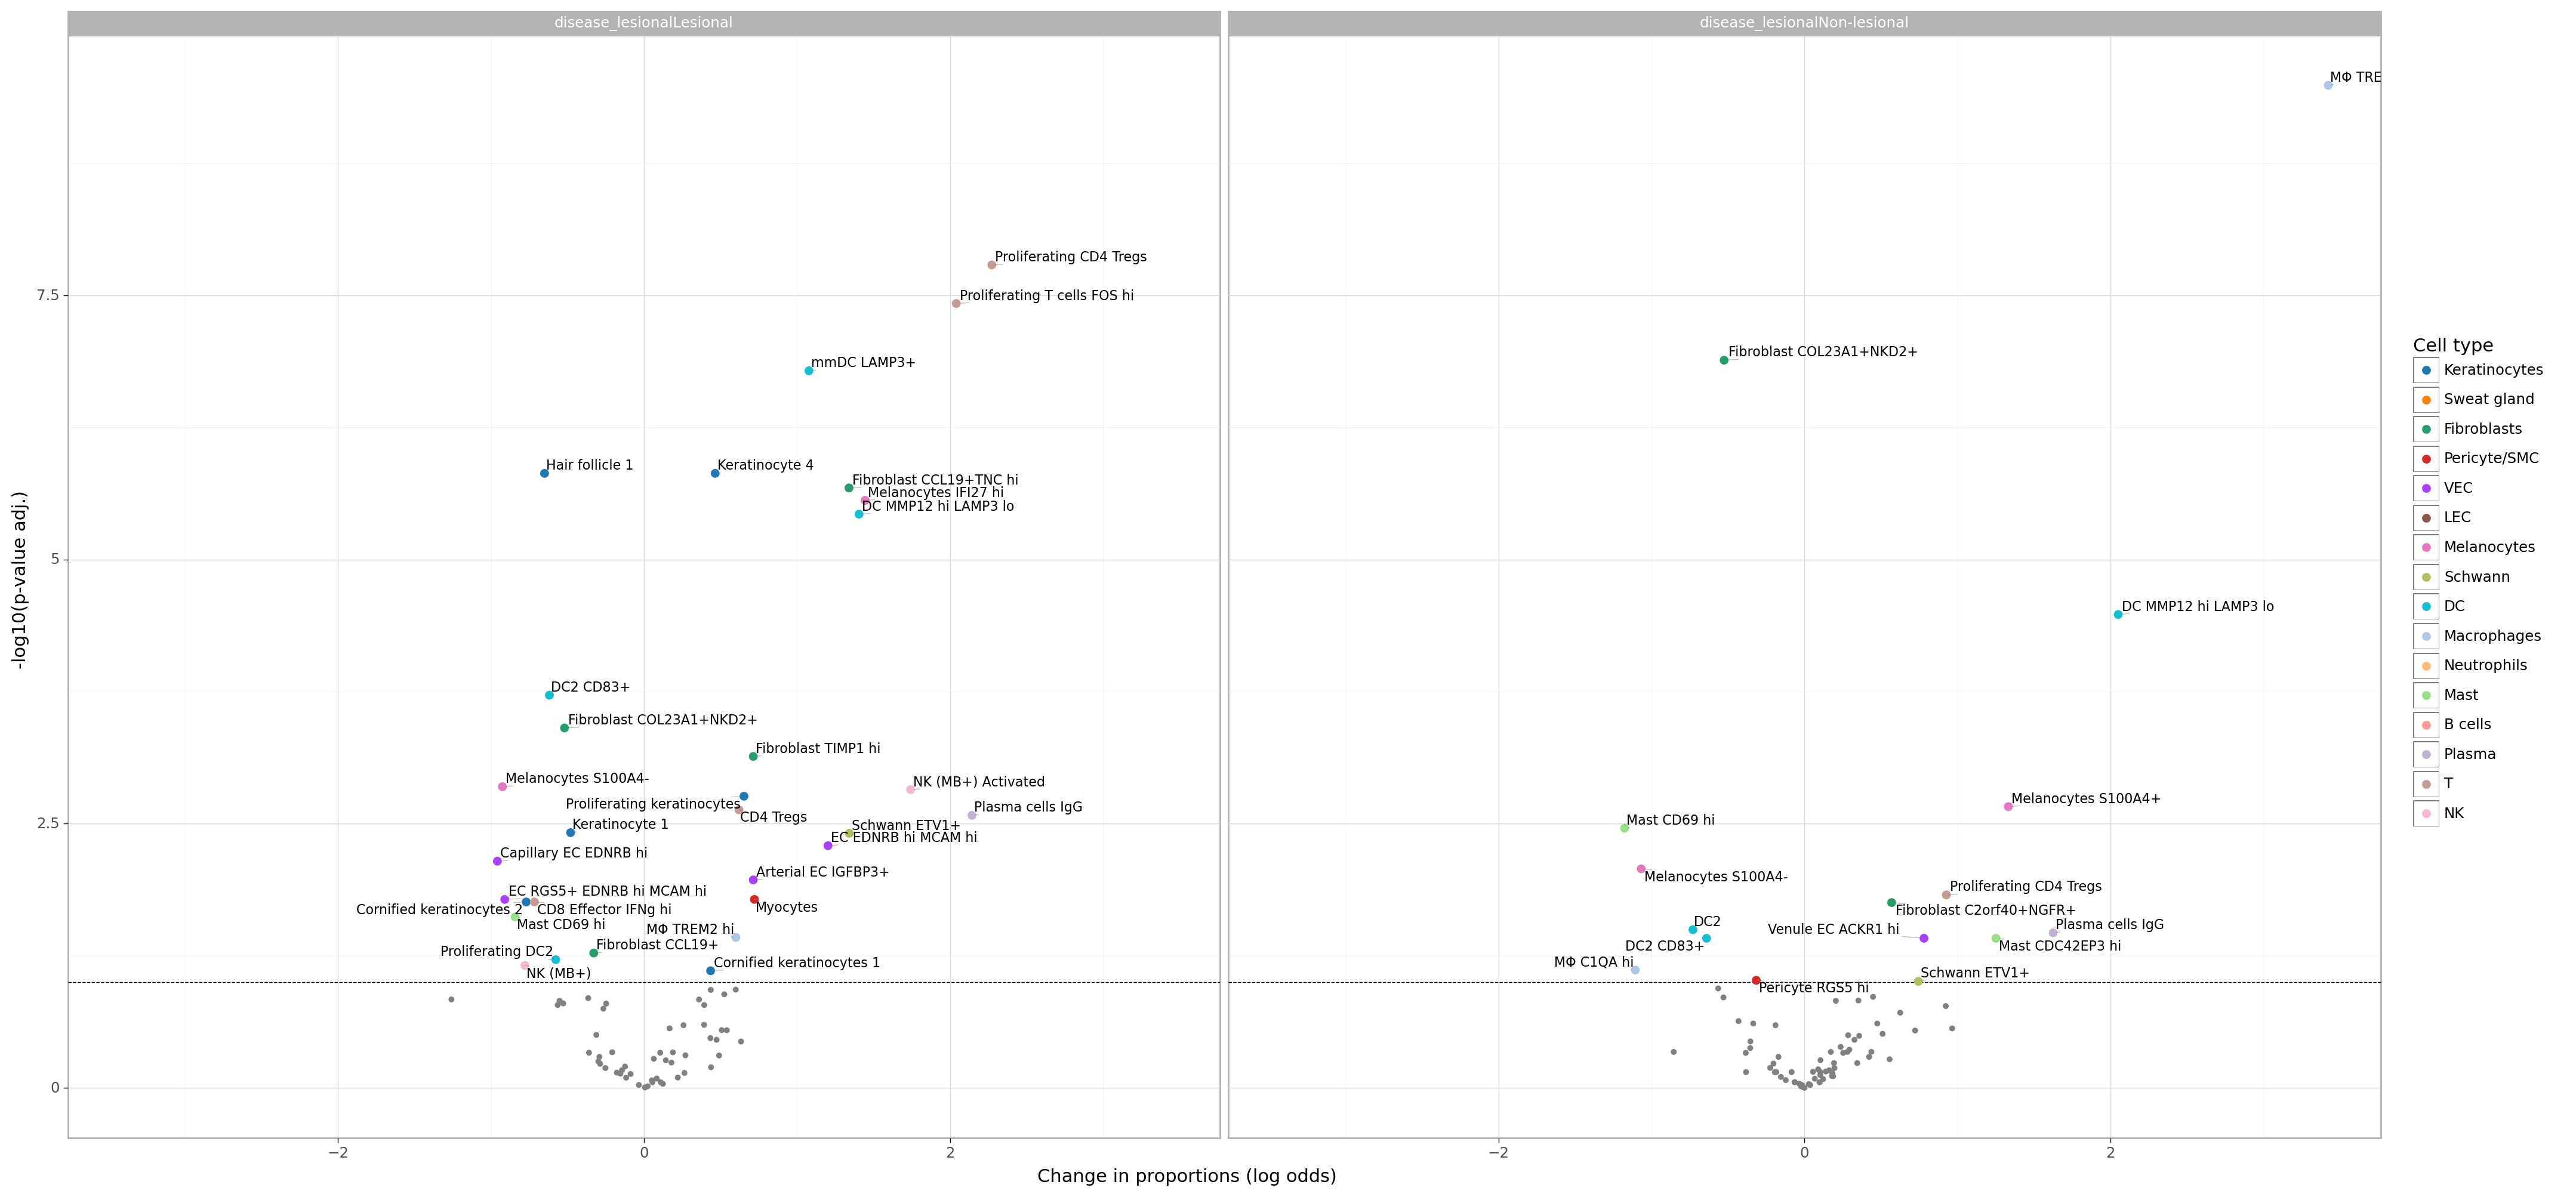

<ggplot: (8751787398087)>

In [52]:
sig = proportion_result[proportion_result.significant]
nonsig = proportion_result[~proportion_result.significant]
color_dict = {k:v for k,v in zip(ad.obs['Cell type'].cat.categories, ad.uns['Cell type_colors'])}

g = (
    ggplot(data=sig, mapping=aes(x='coefficient', y='neg_log10_pval_adj')) + 
    geom_abline(intercept=1, slope=0, color='black', size=.3, linetype='dashed') +     
    geom_point(data=nonsig, size=1, color='gray') + 
    geom_point(aes(color='Cell type'), size=2) + 
    facet_wrap('variable', nrow=1) + 
    geom_text(aes(label='compartment'), size=8, 
              adjust_text={'x': sig.coefficient.values, 'y': sig.neg_log10_pval_adj.values, 
                           #'expand_points': (2,1.5), 
                           'arrowprops': {
                               'arrowstyle': '-', 
                               'color': 'gray', 
                               'lw': 0.5, 
                               'alpha': 0.5
                           }}) +
    scale_color_manual(values=color_dict) + 
    scale_x_continuous(limits=(-sig.coefficient.abs().max(), sig.coefficient.abs().max())) +
    labs(x='Change in proportions (log odds)', y='-log10(p-value adj.)') +
    theme_light() +
    theme(figure_size=(25,12))
)

ggsave(g, 'figures/volcano-proportion-granular-les-nonles.pdf')

g

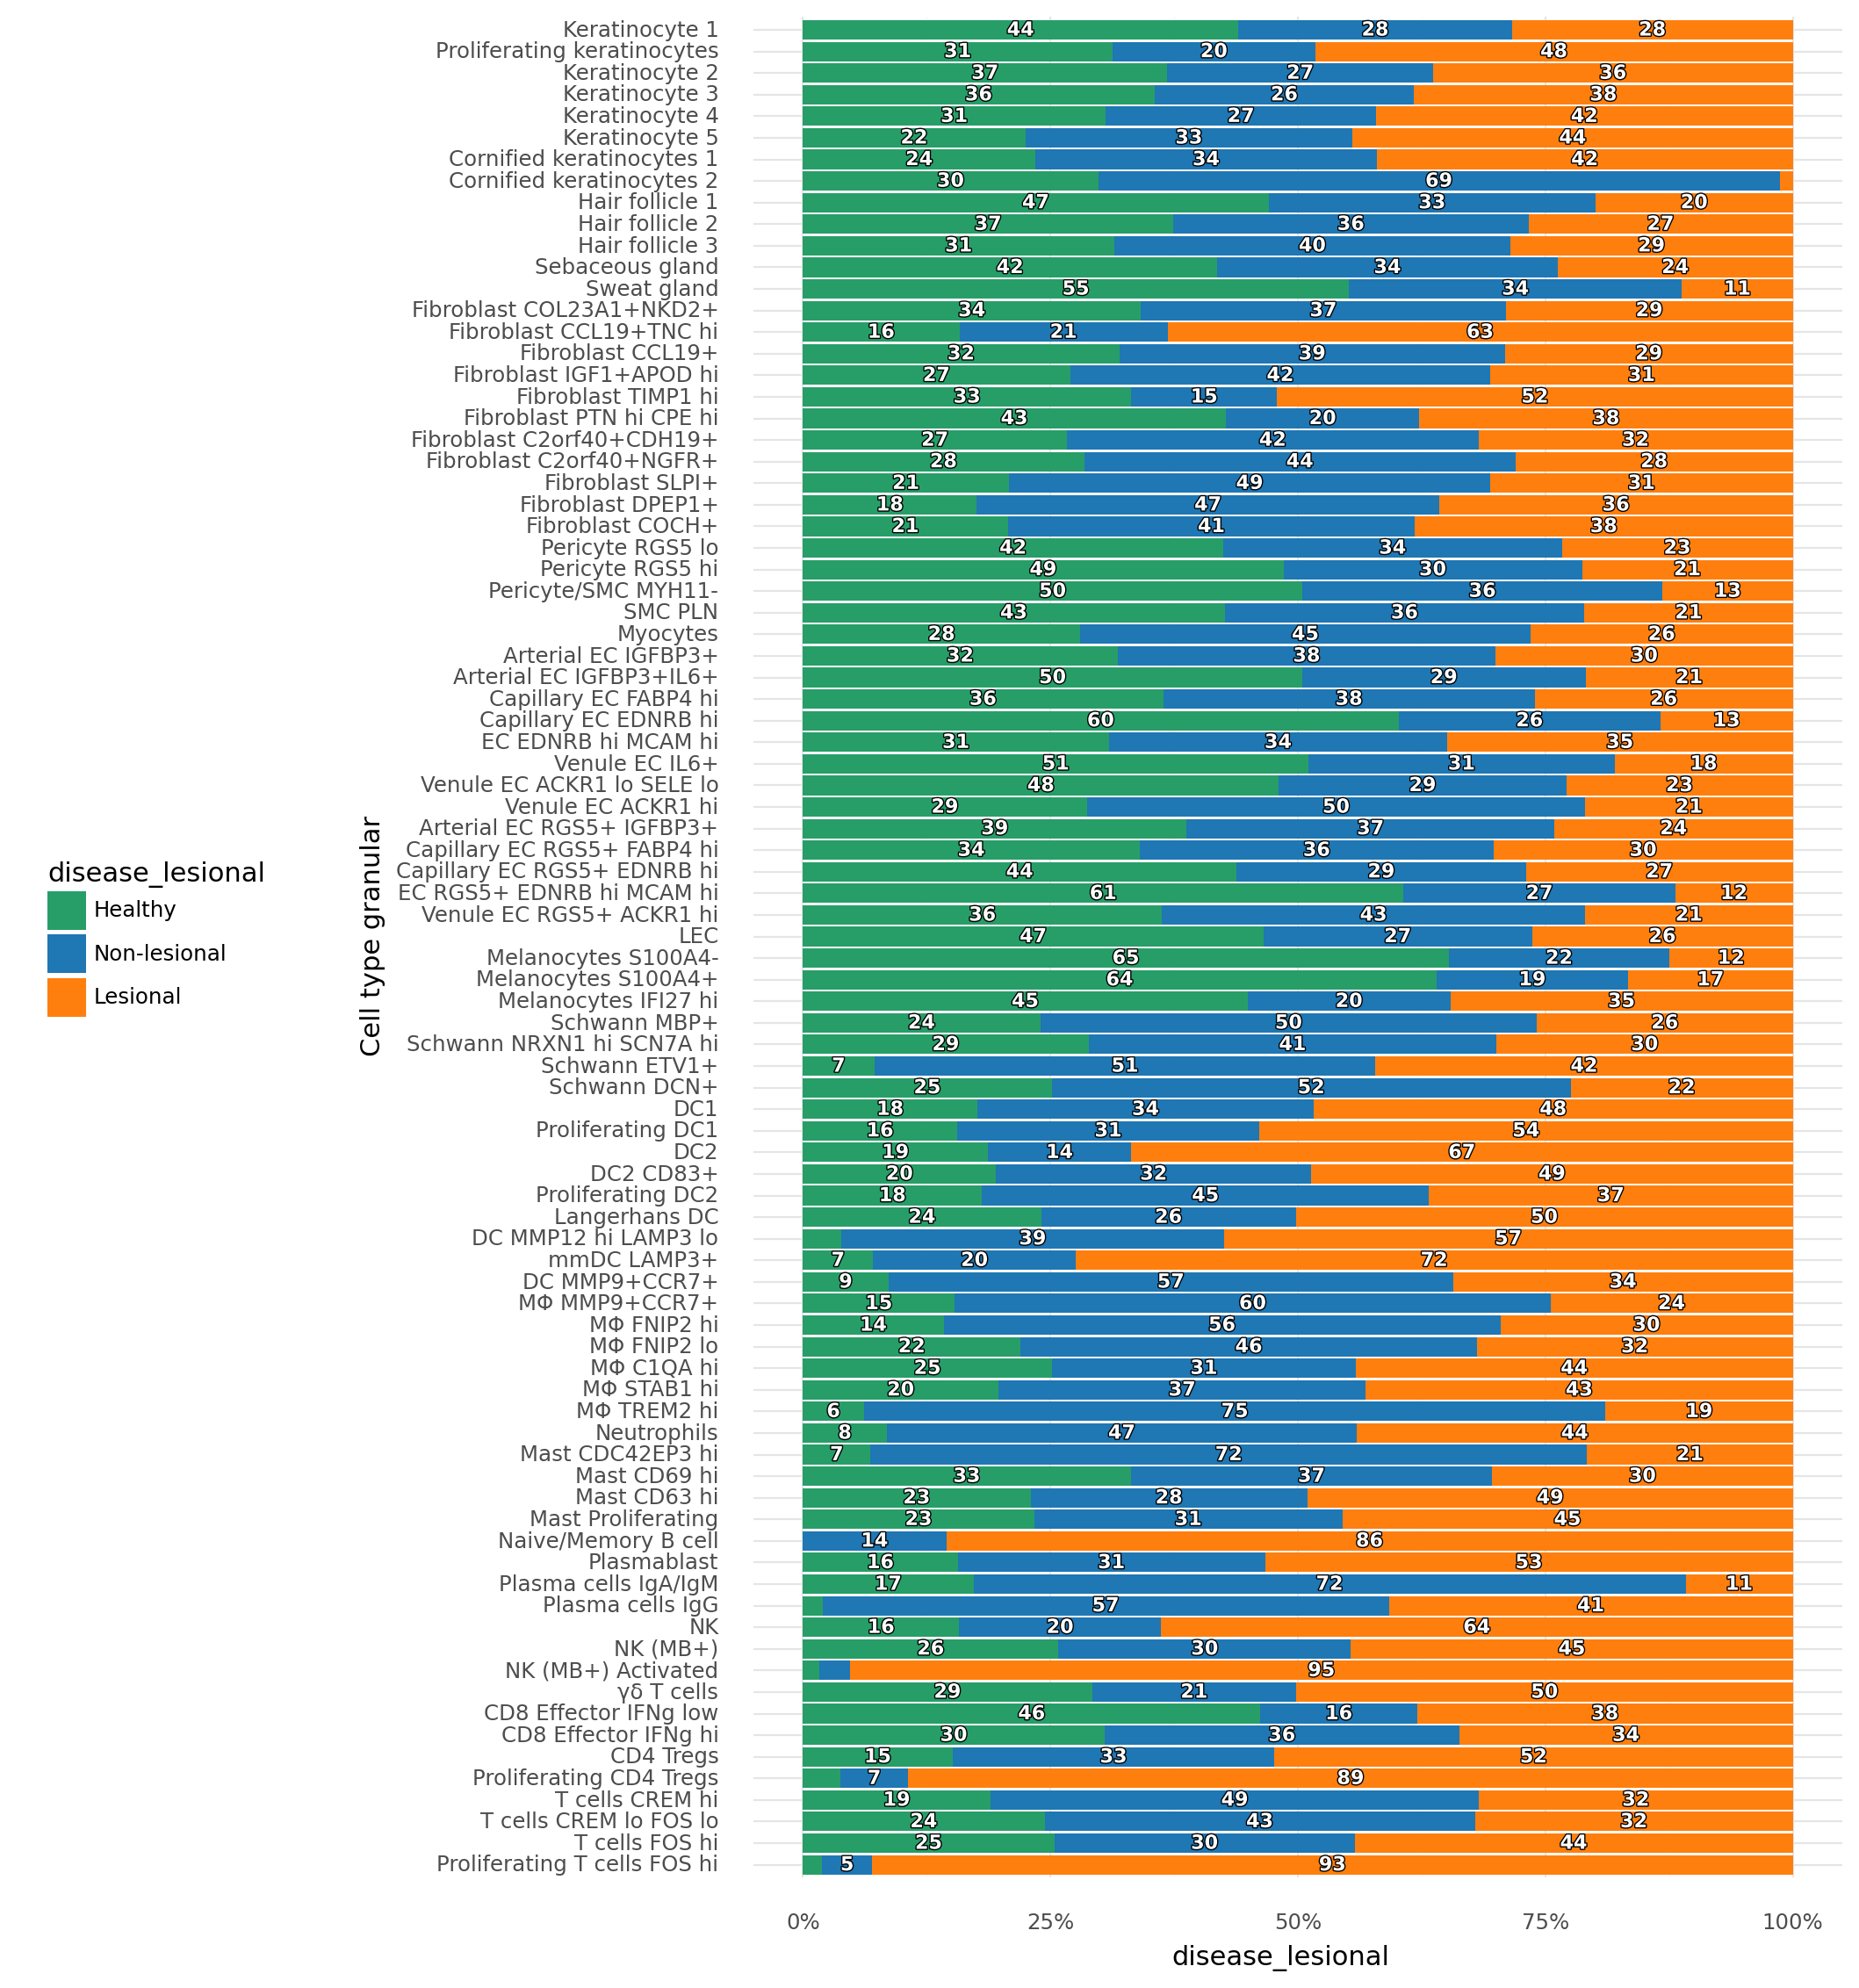

<ggplot: (8750773877782)>

In [54]:
g, df = plot_proportion_barplot(adata, 'Cell type granular', 'disease_lesional', normalize_by='disease_lesional', height_scale=0.4, return_df=True)
g

In [55]:
df[['Cell type granular', 'disease_lesional', 'counts_coarse']].drop_duplicates().pivot('Cell type granular', 'disease_lesional', 'counts_coarse').sort_index(ascending=False).to_excel('proportions-h-nl-l-celltypegranular.xlsx')

In [56]:
pd.crosstab(adata.obs['Cell type granular'], adata.obs.disease_lesional).to_excel('proportions-cellcounts-h-nl-l-celltypegranular.xlsx')

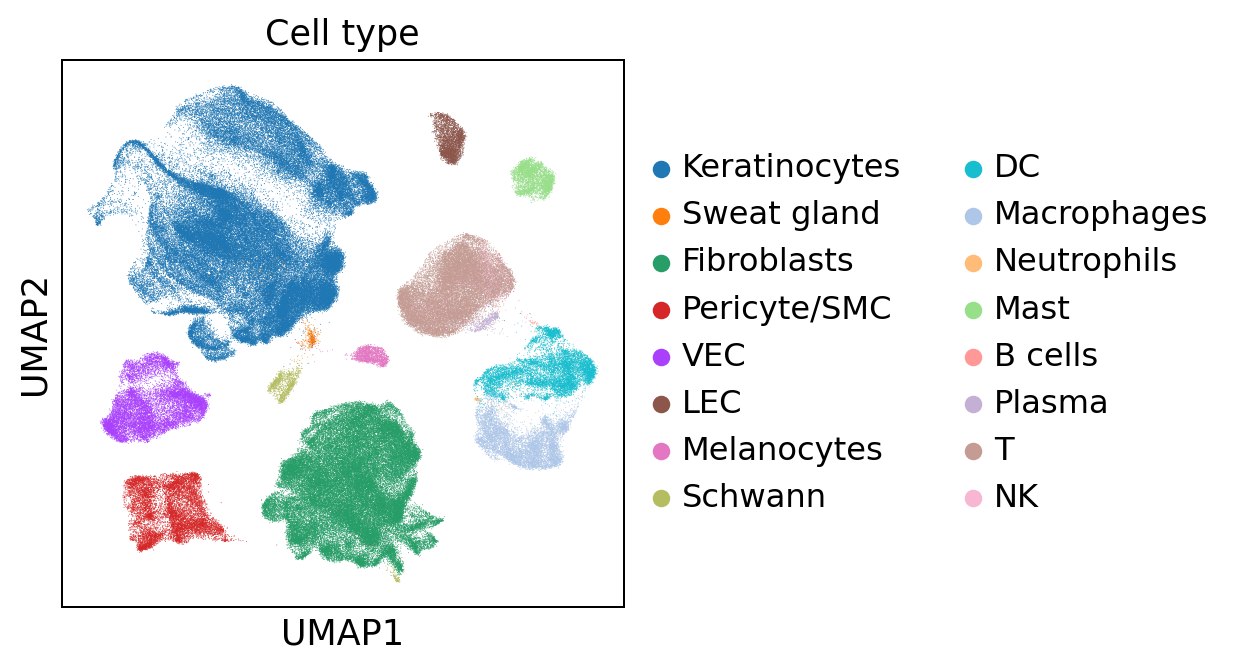

In [57]:
sc.pl.umap(ad, color='Cell type')

In [58]:
ad[ad.obs['Cell type'] == 'NK']

View of AnnData object with n_obs × n_vars = 1260 × 29991
    obs: '10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'predicted_sex', 'raw', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell type', 'Cell type granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'childbearing_potential', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease score (MADAD Immune)', 'Disease score (MADAD Full)', 'Disease score (MADAD Union)', 'Cell type new cornified', 'ind_disease_lesional'
    var

## Visualize proportions (from entire dataset)

In [21]:
props, covs = get_proportions_per_channel(ad, 'channel', 'Cell type granular', ['chemistry_10x', 'disease_lesional'])
props = props.reset_index().melt('channel', var_name='Cell type granular', value_name='proportion')
proportion_df = props.merge(covs.reset_index())
proportion_df['Cell type granular'] = pd.Categorical(proportion_df['Cell type granular'], ad.obs['Cell type granular'].cat.categories)
proportion_df['celltype'] = [t2t.get(x, 'Cornified keratinocytes') for x in proportion_df['Cell type granular']]
proportion_df['celltype'] = pd.Categorical(proportion_df['celltype'], ad.obs['Cell type'].cat.categories)

In [22]:
proportion_df.celltype.cat.categories

Index(['Keratinocytes', 'Sweat gland', 'Fibroblasts', 'Pericyte/SMC', 'VEC',
       'LEC', 'Melanocytes', 'Schwann', 'DC', 'Macrophages', 'Neutrophils',
       'Mast', 'B cells', 'Plasma', 'T', 'NK'],
      dtype='object')

In [23]:
proportion_df

,channel,Cell type granular,proportion,chemistry_10x,disease_lesional,celltype
0,Healthy1-H1,Keratinocyte 1,0.212825,v3,Healthy,Keratinocytes
1,Healthy1-H1,Proliferating keratinocytes,0.035866,v3,Healthy,Keratinocytes
2,Healthy1-H1,Keratinocyte 2,0.106692,v3,Healthy,Keratinocytes
3,Healthy1-H1,Keratinocyte 3,0.157421,v3,Healthy,Keratinocytes
4,Healthy1-H1,Keratinocyte 4,0.066290,v3,Healthy,Keratinocytes
...,...,...,...,...,...,...
2833,MGH110-L,Proliferating CD4 Tregs,0.007880,v3,Lesional,T
2834,MGH110-L,T cells CREM hi,0.005358,v3,Lesional,T
2835,MGH110-L,T cells CREM lo FOS lo,0.008090,v3,Lesional,T
2836,MGH110-L,T cells FOS hi,0.065350,v3,Lesional,T


In [17]:
proportion_df['disease_lesional'] = pd.Categorical(proportion_df['disease_lesional'], categories=['Healthy', 'Non-lesional', 'Lesional'])

(
    ggplot(proportion_df, aes(x='Cell type granular', y='proportion+0.001', fill='disease_lesional')) + 
    geom_dotplot(position='dodge', binaxis = "y", stackdir = "center", binwidth = 0.03) + 
    scale_fill_manual(values=['#4F9B6C', '#3C75AF',  '#EF8636']) + 
    labs(y='Proportions', x='', fill='Disease status') + 
    theme_classic() + 
    scale_y_continuous(trans='log10') + 
    theme(figure_size=(35,6), axis_text_x = element_text(angle = 90, hjust = 1))
)

(
    ggplot(proportion_df, aes(x='cellstate', y='proportion+0.001', fill='disease_lesional')) + 
    geom_dotplot(position='dodge', binaxis = "y", stackdir = "center", binwidth = 0.03) + 
    scale_fill_manual(values=['#4F9B6C', '#3C75AF',  '#EF8636']) + 
    labs(y='Proportions', x='', fill='Disease status') + 
    theme_classic() + 
    scale_y_continuous(trans='log10') + 
    theme(figure_size=(35,6), axis_text_x = element_text(angle = 90, hjust = 1))
)

(
    ggplot(proportion_df, aes(x='Cell type granular', y='proportion+0.001', fill='disease_lesional')) + 
    #geom_dotplot(position='dodge', binaxis = "y", stackdir = "center", binwidth = 0.03) + 
    geom_boxplot() + 
    scale_fill_manual(values=['#4F9B6C', '#3C75AF',  '#EF8636']) + 
    labs(y='Proportions', x='', fill='Disease status') + 
    theme_classic() + 
    #scale_y_continuous(trans='log10') + 
    theme(figure_size=(35,6), axis_text_x = element_text(angle = 90, hjust = 1))
)

(
    ggplot(proportion_df, aes(x='Cell type granular', y='proportion+0.001', fill='disease_lesional')) + 
    #geom_dotplot(position='dodge', binaxis = "y", stackdir = "center", binwidth = 0.03) + 
    geom_boxplot() + 
    scale_fill_manual(values=['#4F9B6C', '#3C75AF',  '#EF8636']) + 
    labs(y='Proportions', x='', fill='Disease status') + 
    theme_classic() + 
    #scale_y_continuous(trans='log10') + 
    theme(figure_size=(35,6), axis_text_x = element_text(angle = 90, hjust = 1))
)

## Keratinocyte proportion boxplots

In [24]:
proportion_df[proportion_df.celltype.isin(['Keratinocytes','Cornified keratinocytes'])]['Cell type granular'].cat.categories

Index(['Keratinocyte 1', 'Proliferating keratinocytes', 'Keratinocyte 2',
       'Keratinocyte 3', 'Keratinocyte 4', 'Keratinocyte 5',
       'Cornified keratinocytes 1', 'Cornified keratinocytes 2',
       'Hair follicle 1', 'Hair follicle 2', 'Hair follicle 3',
       'Sebaceous gland', 'Sweat gland', 'Fibroblast COL23A1+NKD2+',
       'Fibroblast CCL19+TNC hi', 'Fibroblast CCL19+',
       'Fibroblast IGF1+APOD hi', 'Fibroblast TIMP1 hi',
       'Fibroblast PTN hi CPE hi', 'Fibroblast C2orf40+CDH19+',
       'Fibroblast C2orf40+NGFR+', 'Fibroblast SLPI+', 'Fibroblast DPEP1+',
       'Fibroblast COCH+', 'Pericyte RGS5 lo', 'Pericyte RGS5 hi',
       'Pericyte/SMC MYH11-', 'SMC PLN', 'Myocytes', 'Arterial EC IGFBP3+',
       'Arterial EC IGFBP3+IL6+', 'Capillary EC FABP4 hi',
       'Capillary EC EDNRB hi', 'EC EDNRB hi MCAM hi', 'Venule EC IL6+',
       'Venule EC ACKR1 lo SELE lo', 'Venule EC ACKR1 hi',
       'Arterial EC RGS5+ IGFBP3+', 'Capillary EC RGS5+ FABP4 hi',
       'Capill

In [25]:
kera_cats = ['Keratinocyte 1', 'Proliferating keratinocytes', 'Keratinocyte 2', 'Keratinocyte 3', 'Keratinocyte 4', 'Keratinocyte 5']

In [26]:
pd.crosstab(ad[ad.obs['Cell type granular'].isin(kera_cats)].obs.channel, ad[ad.obs['Cell type granular'].isin(kera_cats)].obs['Cell type granular'], normalize=0)#[['Keratinocyte 1', 'Proliferating keratinocytes', 'Keratinocyte 2', 'Keratinocyte 3', 'Keratinocyte 4', 'Keratinocyte 5']]

Cell type granular,Keratinocyte 1,Proliferating keratinocytes,Keratinocyte 2,Keratinocyte 3,Keratinocyte 4,Keratinocyte 5
channel,,,,,,
Healthy1-H1,0.363528,0.061263,0.182241,0.268892,0.113230,0.010846
Healthy2-H2,0.472562,0.049349,0.140150,0.230754,0.096131,0.011054
Healthy5-H51,0.448404,0.052111,0.163749,0.242842,0.083419,0.009475
Healthy5-H52,0.464560,0.051964,0.152983,0.242153,0.080441,0.007899
Healthy6-H6,0.422010,0.049393,0.145581,0.297227,0.071057,0.014731
Healthy7-H7,0.264744,0.038882,0.191350,0.373962,0.101791,0.029270
Healthy8-H8,0.402128,0.032979,0.163830,0.315957,0.078723,0.006383
BCH01-NL1,0.305649,0.034100,0.146025,0.288494,0.171757,0.053975
BCH01-NL2,0.309836,0.037164,0.152696,0.273884,0.177540,0.048879


(
    ggplot(proportion_df[proportion_df['Cell type granular'].isin([
        'Keratinocyte 1', 'Proliferating keratinocytes', 'Keratinocyte 2',
        'Keratinocyte 3', 'Keratinocyte 4', 'Keratinocyte 5'])],
           aes(x='Cell type granular', y='proportion+0.001', fill='disease_lesional')) + 
    #geom_dotplot(position='dodge', binaxis = "y", stackdir = "center", binwidth = 0.03) + 
    geom_boxplot() + 
    scale_fill_manual(values=['#4F9B6C', '#3C75AF',  '#EF8636']) + 
    labs(y='Proportions', x='', fill='Disease status') + 
    theme_classic() + 
    #scale_y_continuous(trans='log10') + 
    theme(figure_size=(6,7.5), axis_text_x = element_text(angle = 90, hjust = 1))
)

(
    ggplot(proportion_df[proportion_df['Cell type granular'].isin([
        'Cornified keratinocytes 1', 'Cornified keratinocytes 2'])],
           aes(x='Cell type granular', y='proportion+0.001', fill='disease_lesional')) + 
    #geom_dotplot(position='dodge', binaxis = "y", stackdir = "center", binwidth = 0.03) + 
    geom_boxplot() + 
    scale_fill_manual(values=['#4F9B6C', '#3C75AF',  '#EF8636']) + 
    labs(y='Proportions', x='', fill='Disease status') + 
    theme_classic() + 
    #scale_y_continuous(trans='log10') + 
    theme(figure_size=(2,7.5), axis_text_x = element_text(angle = 90, hjust = 1))
)

In [27]:
kera_pdf = proportion_df[proportion_df.celltype.str.contains('eratinocyte')]

In [28]:
kera_pdf['ctg'] = kera_pdf['Cell type granular']

<ipython-input-28-35d23902cc15>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [37]:
kera_pdf['Cell type granular v2'] = kera_pdf['Cell type granular'].map(m)

<ipython-input-37-afec4162eb43>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [29]:
from plotnine import *

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 12 x 4 in image



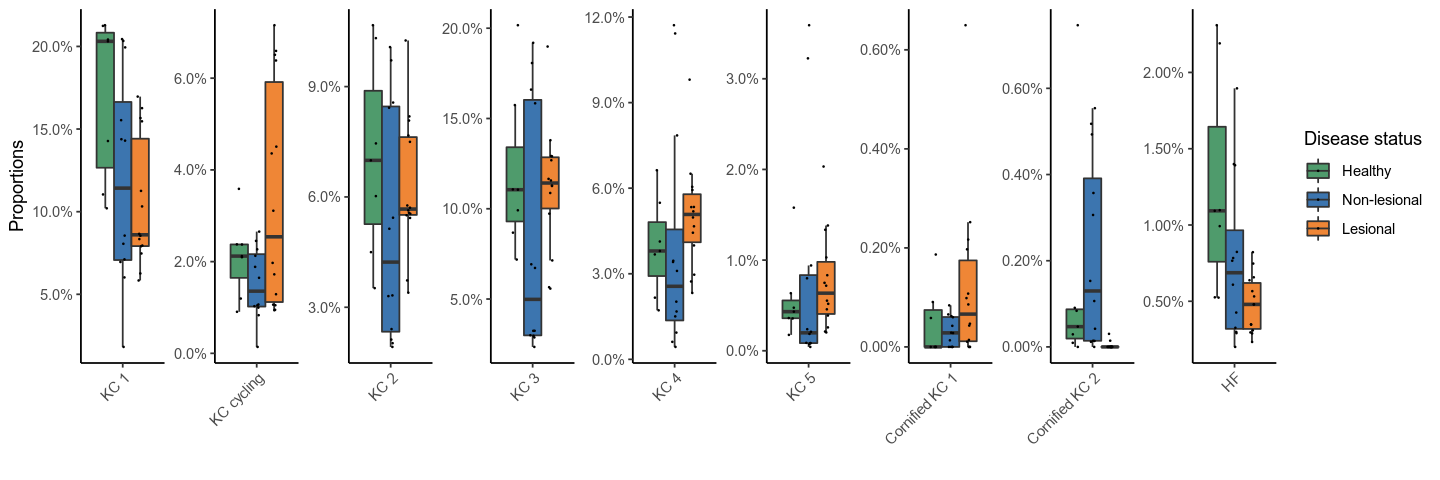

In [38]:
%%R -i kera_pdf -w 12 -h 4 -u in -r 120

library(ggplot2)

g = (
    ggplot(kera_pdf, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~ctg, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Proportions', x='', fill='Disease status')
)

ggsave('figures/figure01/proportions-boxplot-keratinocytes.pdf', useDingbats=F)
g

%%R -i proportion_df -w 25 -h 7 -u in -r 120

library(ggplot2)

(
    ggplot(proportion_df[!proportion_df$celltype %in% c('Fibroblasts', 'Keratinocytes', 'T/NK'),], aes(x=`Cell type granular`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge') + 
    facet_grid(.~celltype, scales='free', space='free') + 
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    labs(y='Proportions', x='', fill='Disease status')
)

%%R -i proportion_df -w 25 -h 7 -u in -r 120

library(ggplot2)

(
    ggplot(proportion_df[proportion_df$celltype %in% c('Fibroblasts', 'Keratinocytes', 'T/NK'),], aes(x=`Cell type granular`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge') + 
    facet_grid(.~celltype, scales='free', space='free') + 
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    labs(y='Proportions', x='', fill='Disease status')
)

(ggplot(proportion_df, aes(x='Cell type granular', y='proportion', fill='disease_lesional')) + 
 geom_boxplot(position='dodge', width=1) + 
 facet_wrap('celltype', ncol=6, scales='free') + 
 theme_classic() + 
 theme(figure_size=(25,15), panel_spacing_y=2., panel_spacing_x=0.5, axis_text_x = element_text(angle = 90, hjust = 1)) + 
 scale_fill_manual(values=['#4F9B6C', '#3C75AF',  '#EF8636']) + 
 #scale_y_continuous(trans='log10') + 
 labs(y='Proportions', x='', fill='Disease status'))

## Myeloids proportions

In [18]:
ad.obs['Cell type granular'].cat.categories

Index(['Keratinocyte 1', 'Proliferating keratinocytes', 'Keratinocyte 2',
       'Keratinocyte 3', 'Keratinocyte 4', 'Keratinocyte 5',
       'Cornified keratinocytes 1', 'Cornified keratinocytes 2',
       'Hair follicle 1', 'Hair follicle 2', 'Hair follicle 3',
       'Sebaceous gland', 'Sweat gland', 'Fibroblast COL23A1+NKD2+',
       'Fibroblast CCL19+TNC hi', 'Fibroblast CCL19+',
       'Fibroblast IGF1+APOD hi', 'Fibroblast TIMP1 hi',
       'Fibroblast PTN hi CPE hi', 'Fibroblast C2orf40+CDH19+',
       'Fibroblast C2orf40+NGFR+', 'Fibroblast SLPI+', 'Fibroblast DPEP1+',
       'Fibroblast COCH+', 'Pericyte RGS5 lo', 'Pericyte RGS5 hi',
       'Pericyte/SMC MYH11-', 'SMC PLN', 'Myocytes', 'Arterial EC IGFBP3+',
       'Arterial EC IGFBP3+IL6+', 'Capillary EC FABP4 hi',
       'Capillary EC EDNRB hi', 'EC EDNRB hi MCAM hi', 'Venule EC IL6+',
       'Venule EC ACKR1 lo SELE lo', 'Venule EC ACKR1 hi',
       'Arterial EC RGS5+ IGFBP3+', 'Capillary EC RGS5+ FABP4 hi',
       'Capill

In [19]:
props, covs = get_proportions_per_channel(ad, 'channel', 'Cell type granular', ['chemistry_10x', 'disease_lesional'], groups=['DC1', 'Proliferating DC1', 'DC2', 'DC2 CD83+', 'Proliferating DC2', 'Langerhans DC', 'DC MMP12 hi LAMP3 lo', 'mmDC LAMP3+', 'DC MMP9+CCR7+', 'MΦ MMP9+CCR7+', 'MΦ FNIP2 hi', 'MΦ FNIP2 lo', 'MΦ C1QA hi','MΦ STAB1 hi', 'MΦ TREM2 hi'])
props = props.reset_index().melt('channel', var_name='Cell type granular', value_name='proportion')
proportion_df = props.merge(covs.reset_index())
proportion_df['Cell type granular'] = pd.Categorical(proportion_df['Cell type granular'], ad.obs['Cell type granular'].cat.categories)
proportion_df['celltype'] = [t2t.get(x, 'Cornified keratinocytes') for x in proportion_df['Cell type granular']]
proportion_df['celltype'] = pd.Categorical(proportion_df['celltype'], ad.obs['Cell type'].cat.categories)

In [20]:
proportion_df.celltype.cat.categories

Index(['Keratinocytes', 'Cornified keratinocytes', 'Sweat gland',
       'Fibroblasts', 'Pericyte/SMC', 'VEC', 'LEC', 'Melanocytes', 'Schwann',
       'DC', 'Macrophages', 'Neutrophils', 'Mast', 'B cells', 'Plasma',
       'T/NK'],
      dtype='object')

In [21]:
proportion_df['disease_lesional'] = pd.Categorical(proportion_df['disease_lesional'], categories=['Healthy', 'Non-lesional', 'Lesional'])

In [22]:
proportion_df['Cell type granular v2'] = proportion_df['Cell type granular'].map(m)

In [24]:
proportion_df[['channel','disease_lesional']].drop_duplicates()['disease_lesional'].value_counts()

Lesional        14
Non-lesional    12
Healthy          7
Name: disease_lesional, dtype: int64

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


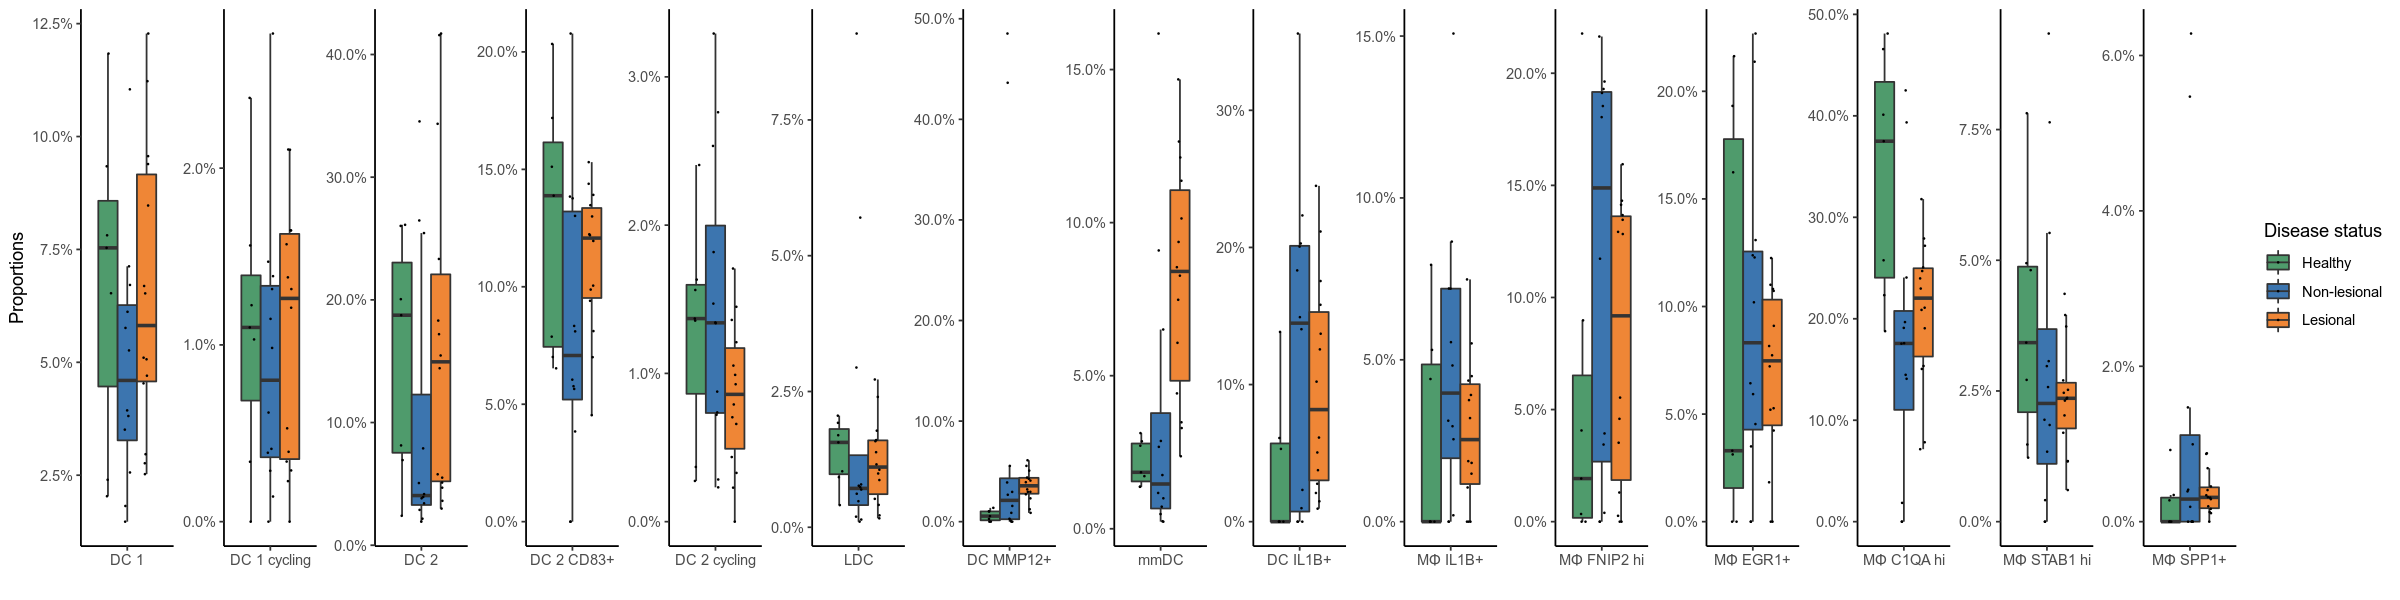

In [25]:
%%R -i proportion_df -w 20 -h 5 -u in -r 120

library(ggplot2)

g = (
    ggplot(proportion_df, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +        
    facet_wrap(~`Cell type granular`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Proportions', x='', fill='Disease status')
)

#ggsave('figures/myeloids/boxplot-myeloid-proportions.pdf', device=cairo_pdf)

g

## Lymphocyte proportions

In [48]:
ad.obs['Cell type granular'].cat.categories

Index(['Keratinocyte 1', 'Proliferating keratinocytes', 'Keratinocyte 2',
       'Keratinocyte 3', 'Keratinocyte 4', 'Keratinocyte 5',
       'Cornified keratinocytes 1', 'Cornified keratinocytes 2',
       'Hair follicle 1', 'Hair follicle 2', 'Hair follicle 3',
       'Sebaceous gland', 'Sweat gland', 'Fibroblast COL23A1+NKD2+',
       'Fibroblast CCL19+TNC hi', 'Fibroblast CCL19+',
       'Fibroblast IGF1+APOD hi', 'Fibroblast TIMP1 hi',
       'Fibroblast PTN hi CPE hi', 'Fibroblast C2orf40+CDH19+',
       'Fibroblast C2orf40+NGFR+', 'Fibroblast SLPI+', 'Fibroblast DPEP1+',
       'Fibroblast COCH+', 'Pericyte RGS5 lo', 'Pericyte RGS5 hi',
       'Pericyte/SMC MYH11-', 'SMC PLN', 'Myocytes', 'Arterial EC IGFBP3+',
       'Arterial EC IGFBP3+IL6+', 'Capillary EC FABP4 hi',
       'Capillary EC EDNRB hi', 'EC EDNRB hi MCAM hi', 'Venule EC IL6+',
       'Venule EC ACKR1 lo SELE lo', 'Venule EC ACKR1 hi',
       'Arterial EC RGS5+ IGFBP3+', 'Capillary EC RGS5+ FABP4 hi',
       'Capill

In [88]:
props, covs = get_proportions_per_channel(ad, 'channel', 'Cell type granular', ['chemistry_10x', 'disease_lesional'], groups=[
    'Naive/Memory B cell', 'Plasmablast', 'Plasma cells IgA/IgM', 'Plasma cells IgG',
    'NK', 'NK (MB+)', 'NK (MB+) Activated',
       'γδ T cells', 'CD8 Effector IFNg low', 'CD8 Effector IFNg hi',
       'CD4 Tregs', 'Proliferating CD4 Tregs', 'T cells CREM hi',
       'T cells CREM lo FOS lo', 'T cells FOS hi',
       'Proliferating T cells FOS hi'])
props = props.reset_index().melt('channel', var_name='Cell type granular', value_name='proportion')
proportion_df = props.merge(covs.reset_index())
proportion_df['Cell type granular'] = pd.Categorical(proportion_df['Cell type granular'], ad.obs['Cell type granular'].cat.categories)
proportion_df['celltype'] = [t2t.get(x, 'Cornified keratinocytes') for x in proportion_df['Cell type granular']]
proportion_df['celltype'] = pd.Categorical(proportion_df['celltype'], ad.obs['Cell type'].cat.categories)

In [89]:
proportion_df.celltype.cat.categories

Index(['Keratinocytes', 'Sweat gland', 'Fibroblasts', 'Pericyte/SMC', 'VEC',
       'LEC', 'Melanocytes', 'Schwann', 'DC', 'Macrophages', 'Neutrophils',
       'Mast', 'B cells', 'Plasma', 'T', 'NK'],
      dtype='object')

In [90]:
proportion_df['disease_lesional'] = pd.Categorical(proportion_df['disease_lesional'], categories=['Healthy', 'Non-lesional', 'Lesional'])

In [91]:
proportion_df['Cell type granular v2'] = proportion_df['Cell type granular'].map(m)

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 20 x 5 in image



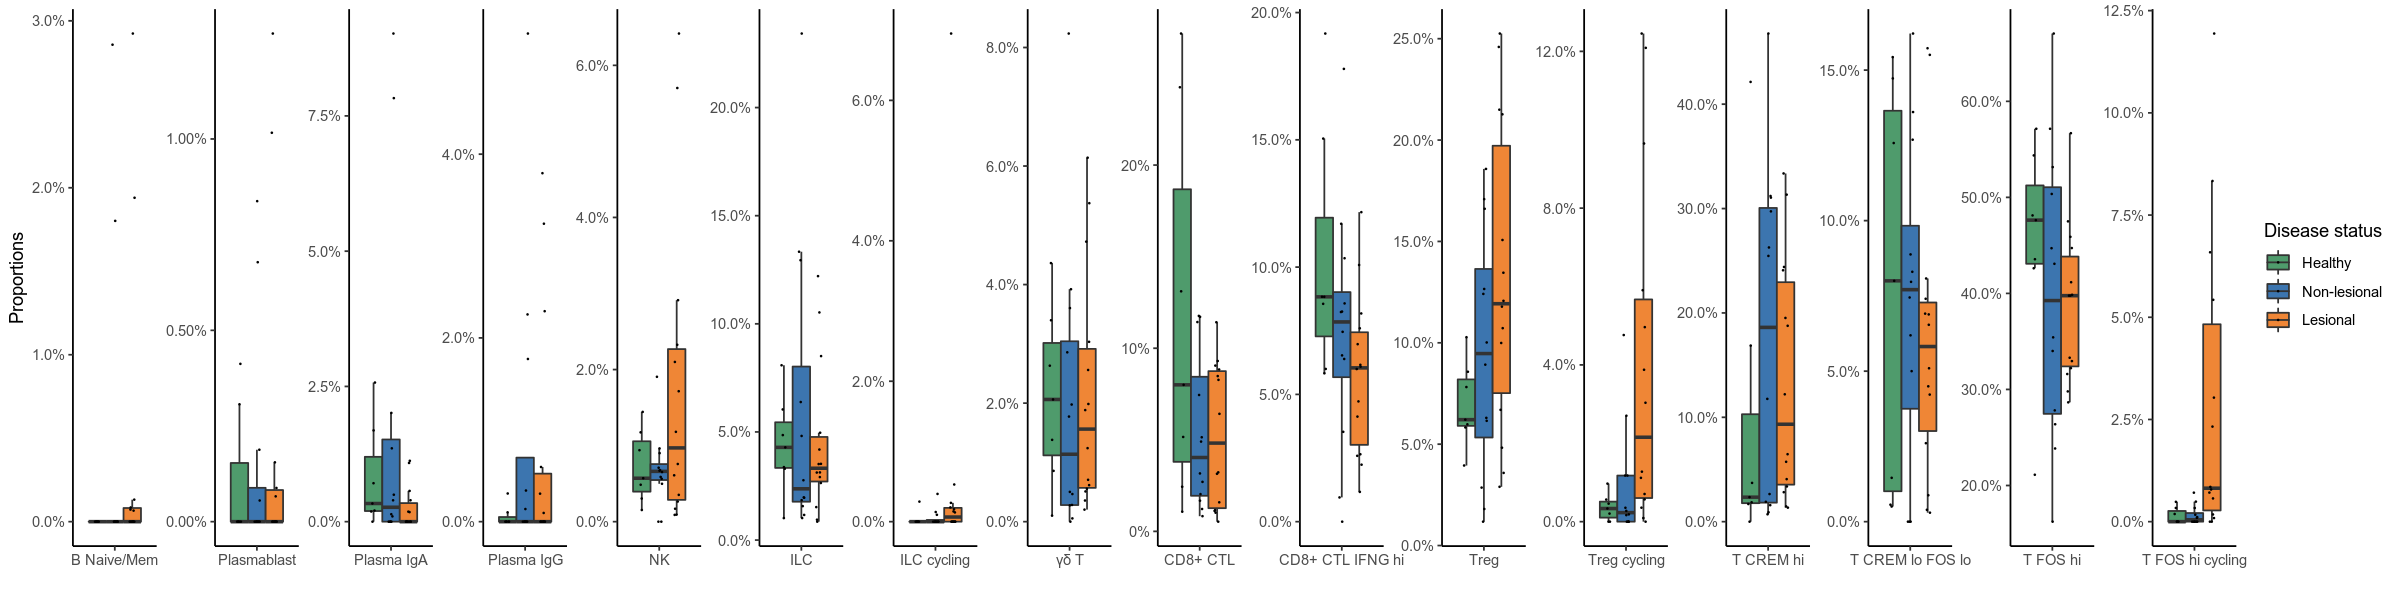

In [92]:
%%R -i proportion_df -w 20 -h 5 -u in -r 120

library(ggplot2)

g = (
    ggplot(proportion_df, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, width.errorbar=0, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +            
    facet_wrap(~`Cell type granular`, scales='free', nrow=1) + 
    theme_classic() + 
    #theme(axis.text.x = element_text(angle = 45, hjust = 1), strip.background=element_blank(), strip.text=element_blank()) + 
    theme(strip.background=element_blank(), strip.text=element_blank()) +     
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Proportions', x='', fill='Disease status')
)

ggsave('figures/lymphocytes//boxplot-lymphocyte-proportions.pdf', device=cairo_pdf)

g

## Stromal proportions

In [58]:
ad.obs['Cell type granular'].cat.categories

Index(['Keratinocyte 1', 'Proliferating keratinocytes', 'Keratinocyte 2',
       'Keratinocyte 3', 'Keratinocyte 4', 'Keratinocyte 5',
       'Cornified keratinocytes 1', 'Cornified keratinocytes 2',
       'Hair follicle 1', 'Hair follicle 2', 'Hair follicle 3',
       'Sebaceous gland', 'Sweat gland', 'Fibroblast COL23A1+NKD2+',
       'Fibroblast CCL19+TNC hi', 'Fibroblast CCL19+',
       'Fibroblast IGF1+APOD hi', 'Fibroblast TIMP1 hi',
       'Fibroblast PTN hi CPE hi', 'Fibroblast C2orf40+CDH19+',
       'Fibroblast C2orf40+NGFR+', 'Fibroblast SLPI+', 'Fibroblast DPEP1+',
       'Fibroblast COCH+', 'Pericyte RGS5 lo', 'Pericyte RGS5 hi',
       'Pericyte/SMC MYH11-', 'SMC PLN', 'Myocytes', 'Arterial EC IGFBP3+',
       'Arterial EC IGFBP3+IL6+', 'Capillary EC FABP4 hi',
       'Capillary EC EDNRB hi', 'EC EDNRB hi MCAM hi', 'Venule EC IL6+',
       'Venule EC ACKR1 lo SELE lo', 'Venule EC ACKR1 hi',
       'Arterial EC RGS5+ IGFBP3+', 'Capillary EC RGS5+ FABP4 hi',
       'Capill

## vec

In [60]:
props, covs = get_proportions_per_channel(ad, 'channel', 'Cell type granular', ['chemistry_10x', 'disease_lesional'], groups=['Arterial EC IGFBP3+',
       'Arterial EC IGFBP3+IL6+', 'Capillary EC FABP4 hi',
       'Capillary EC EDNRB hi', 'EC EDNRB hi MCAM hi', 'Venule EC IL6+',
       'Venule EC ACKR1 lo SELE lo', 'Venule EC ACKR1 hi',
       'Arterial EC RGS5+ IGFBP3+', 'Capillary EC RGS5+ FABP4 hi',
       'Capillary EC RGS5+ EDNRB hi', 'EC RGS5+ EDNRB hi MCAM hi',
       'Venule EC RGS5+ ACKR1 hi'])
props = props.reset_index().melt('channel', var_name='Cell type granular', value_name='proportion')
proportion_df = props.merge(covs.reset_index())
proportion_df['Cell type granular'] = pd.Categorical(proportion_df['Cell type granular'], ad.obs['Cell type granular'].cat.categories)
proportion_df['celltype'] = [t2t.get(x, 'Cornified keratinocytes') for x in proportion_df['Cell type granular']]
proportion_df['celltype'] = pd.Categorical(proportion_df['celltype'], ad.obs['Cell type'].cat.categories)

In [61]:
proportion_df['disease_lesional'] = pd.Categorical(proportion_df['disease_lesional'], categories=['Healthy', 'Non-lesional', 'Lesional'])

In [63]:
proportion_df['Cell type granular'].nunique()*1.3

16.900000000000002

In [62]:
proportion_df['Cell type granular v2'] = proportion_df['Cell type granular'].map(m)

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 17 x 5 in image



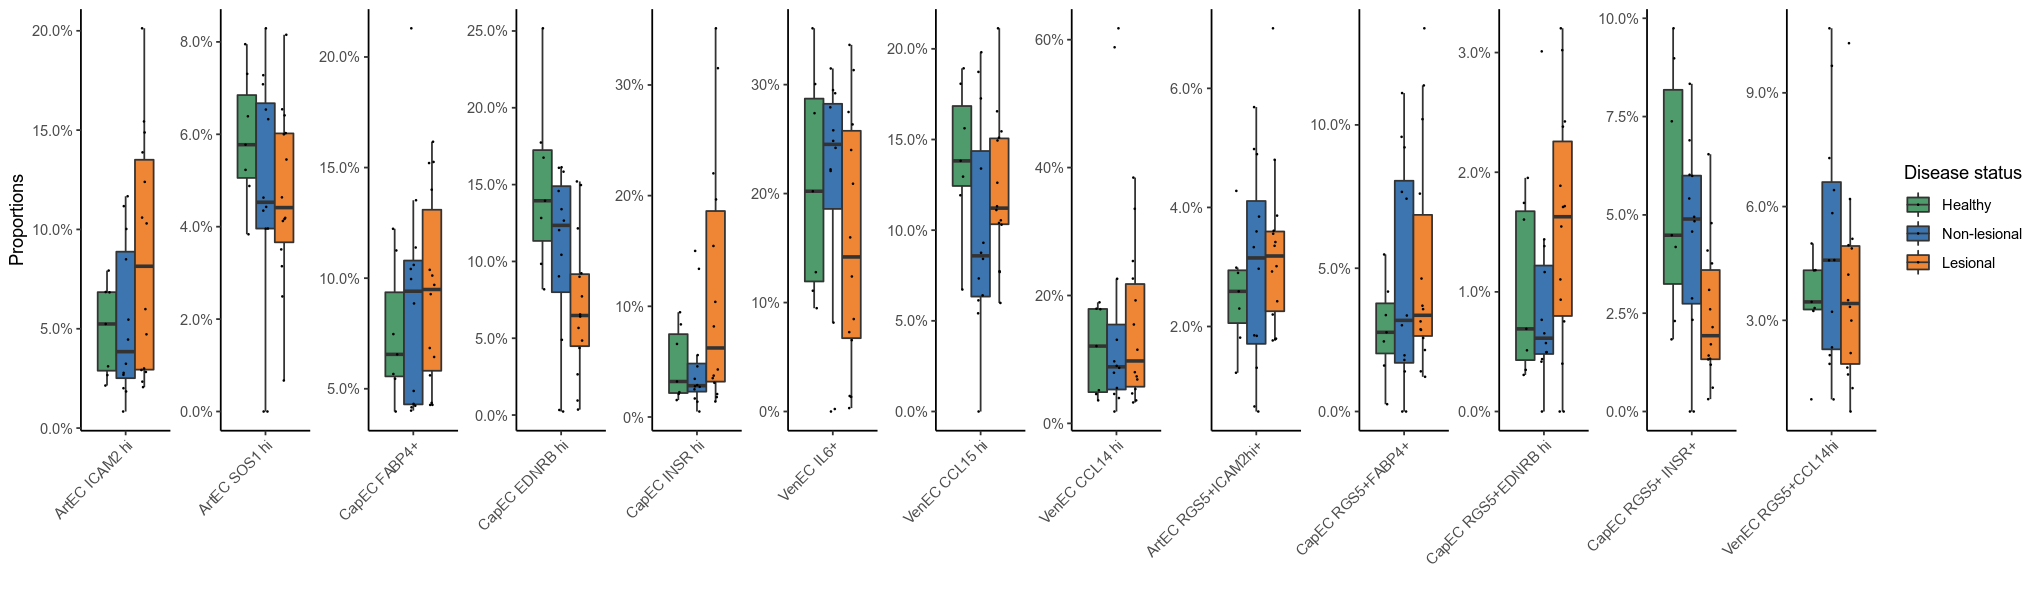

In [64]:
%%R -i proportion_df -w 17 -h 5 -u in -r 120

library(ggplot2)

g = (
    ggplot(proportion_df, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Proportions', x='', fill='Disease status')
)

ggsave('figures/stromal/boxplot-vec-proportions.pdf', device=cairo_pdf)

g

## pericyte

In [66]:
props, covs = get_proportions_per_channel(ad, 'channel', 'Cell type granular', ['chemistry_10x', 'disease_lesional'], groups=['Pericyte RGS5 lo', 'Pericyte RGS5 hi', 'Pericyte/SMC MYH11-', 'SMC PLN', 'Myocytes'])
props = props.reset_index().melt('channel', var_name='Cell type granular', value_name='proportion')
proportion_df = props.merge(covs.reset_index())
proportion_df['Cell type granular'] = pd.Categorical(proportion_df['Cell type granular'], ad.obs['Cell type granular'].cat.categories)
proportion_df['celltype'] = [t2t.get(x, 'Cornified keratinocytes') for x in proportion_df['Cell type granular']]
proportion_df['celltype'] = pd.Categorical(proportion_df['celltype'], ad.obs['Cell type'].cat.categories)

In [67]:
proportion_df['disease_lesional'] = pd.Categorical(proportion_df['disease_lesional'], categories=['Healthy', 'Non-lesional', 'Lesional'])

In [68]:
proportion_df['Cell type granular v2'] = proportion_df['Cell type granular'].map(m)

In [68]:
proportion_df['Cell type granular'].nunique()*1.3

6.5

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 7.5 x 5 in image



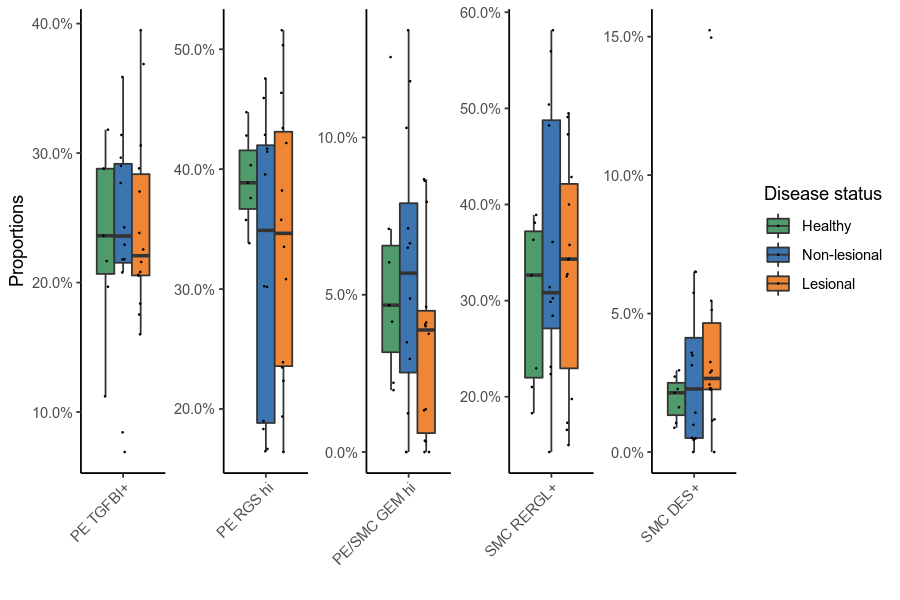

In [70]:
%%R -i proportion_df -w 7.5 -h 5 -u in -r 120

library(ggplot2)

g = (
    ggplot(proportion_df, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Proportions', x='', fill='Disease status')
)

ggsave('figures/stromal/boxplot-pericytesmc-proportions.pdf', device=cairo_pdf)

g

## Fibroblasts

In [72]:
props, covs = get_proportions_per_channel(ad, 'channel', 'Cell type granular', ['chemistry_10x', 'disease_lesional'], groups=[
    'Fibroblast COL23A1+NKD2+',
       'Fibroblast CCL19+TNC hi', 'Fibroblast CCL19+',
       'Fibroblast IGF1+APOD hi', 'Fibroblast TIMP1 hi',
       'Fibroblast PTN hi CPE hi', 'Fibroblast C2orf40+CDH19+',
       'Fibroblast C2orf40+NGFR+', 'Fibroblast SLPI+', 'Fibroblast DPEP1+',
       'Fibroblast COCH+'])
props = props.reset_index().melt('channel', var_name='Cell type granular', value_name='proportion')
proportion_df = props.merge(covs.reset_index())
proportion_df['Cell type granular'] = pd.Categorical(proportion_df['Cell type granular'], ad.obs['Cell type granular'].cat.categories)
proportion_df['celltype'] = [t2t.get(x, 'Cornified keratinocytes') for x in proportion_df['Cell type granular']]
proportion_df['celltype'] = pd.Categorical(proportion_df['celltype'], ad.obs['Cell type'].cat.categories)

In [73]:
proportion_df['disease_lesional'] = pd.Categorical(proportion_df['disease_lesional'], categories=['Healthy', 'Non-lesional', 'Lesional'])

In [74]:
proportion_df['Cell type granular v2'] = proportion_df['Cell type granular'].map(m)

In [74]:
proportion_df['Cell type granular'].nunique()*1.3

14.3

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 14.5 x 5 in image



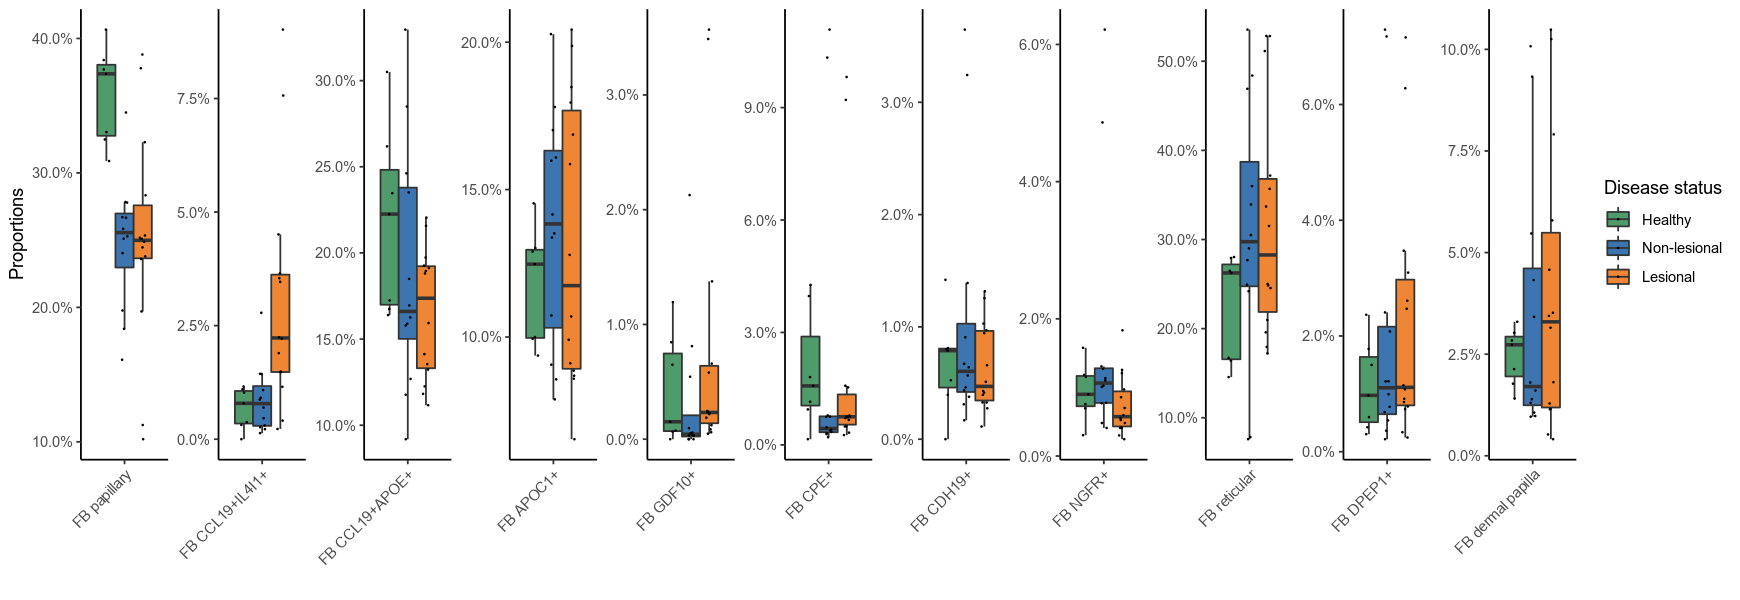

In [75]:
%%R -i proportion_df -w 14.5 -h 5 -u in -r 120

library(ggplot2)

g = (
    ggplot(proportion_df, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +        
    facet_wrap(~`Cell type granular`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Proportions', x='', fill='Disease status')
)

ggsave('figures/stromal/boxplot-fibro-proportions.pdf', device=cairo_pdf)

g